# Can You Trust Post-Hoc Calibration Under Shift?
### Revisiting the Ovadia Benchmark with Modern Calibration Methods

**Core question:** Is temperature scaling good because it is *correct*, or because benchmarks are *easy*?

This notebook documents a full reproduction and extension of [Guo et al. (2017)](https://arxiv.org/abs/1706.04599) and [Ovadia et al. (2019)](https://arxiv.org/abs/1906.02629). We start from scratch: train a DenseNet-BC-40 on CIFAR-100, apply temperature scaling, then stress-test it under 13 types of image corruption at 5 severity levels. After reproducing the original findings, we bring in three modern post-hoc calibrators (ETS, TvA, DAC) that didn't exist when Ovadia was published, and ask whether any of them close the gap.

---

| File | What it does |
|------|-------------|
| `train.py` | Trains DenseNet-BC-40 on CIFAR-100 |
| `demo.py` | Applies a single calibration method and saves the model |
| `temperature_scaling.py` | All calibrators + ECE metrics |
| `corruptions.py` | 13 image corruption types, 5 severity levels each |
| `evaluate_shift.py` | Full benchmark loop: 4 methods × 13 corruptions × 5 severities |
| `plot_per_corruption.py` | Plotting utilities |


In [2]:
import os
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches

from matplotlib.lines import Line2D

from scipy.special import softmax
from scipy.optimize import minimize_scalar





## 1. What is calibration and why should we care?

A neural network outputs a probability vector and the argmax gives the predicted class. Most people stop there and only care about accuracy. But if you're deploying a model in anything that matters (medical diagnosis, autonomous driving, any system that makes decisions based on model output), the *confidence score* carries just as much weight as the prediction itself.

**Calibration** is the property that confidence scores actually mean something. Formally, a model is perfectly calibrated if:

$$\mathbb{P}(\hat{Y} = Y \mid \hat{p} = p) = p \quad \forall\, p \in [0, 1]$$

In plain terms: among all the times the model says "I'm 80% confident", it should be right 80% of the time. 

Modern deep networks almost universally violate this. They tend to be **overconfident** — they output very high probabilities even when they're wrong. This was documented clearly by Guo et al. (2017), who showed that networks trained with standard cross-entropy on large datasets develop a systematic gap between confidence and accuracy.

The practical implication: if you use model confidence as a threshold for human handoff, anomaly detection, or risk scoring, an overconfident model will make you think it's safer than it is.


## 2. Measuring miscalibration: Expected Calibration Error

The standard metric is **ECE** (Expected Calibration Error). The idea is simple: bin predictions by confidence, and for each bin measure how far the average confidence is from the average accuracy. Weight by bin size and sum:

$$\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{n} \left| \text{acc}(B_m) - \text{conf}(B_m) \right|$$

where $B_m$ is the set of samples whose maximum predicted probability falls in bin $m$, $n$ is the total number of samples, and $M$ is the number of bins (we use $M = 15$).

The issue with fixed-width bins is that confidence values tend to cluster near 1 (because models are overconfident), so some bins have thousands of samples and others have zero. **Adaptive ECE** fixes this by using equal-mass bins; every bin gets the same number of samples regardless of where the confidence values land. It's a more honest metric and the one we prefer for reporting under shift.

We also track **NLL** (negative log-likelihood) because it's a *proper scoring rule*: it simultaneously penalizes wrong predictions and overconfident ones, making it a cleaner summary than ECE alone.

$$\text{NLL} = -\frac{1}{n} \sum_{i=1}^{n} \log p_{\theta}(y_i \mid x_i)$$


## 3. Temperature Scaling — the simplest fix

Temperature Scaling (Guo et al. 2017) is almost embarrassingly simple. You take the raw logits $z \in \mathbb{R}^K$ that the network produces and divide them by a single scalar $T > 0$ before the softmax:

$$p_k = \frac{\exp(z_k / T)}{\sum_{j=1}^{K} \exp(z_j / T)}$$

That's it. One parameter. $T$ is fit by minimizing NLL on a held-out validation set using L-BFGS. A value $T > 1$ spreads the distribution out (reduces overconfidence), while $T < 1$ sharpens it.

The key thing to notice: **argmax doesn't change**. Dividing all logits by the same constant can't change which one is largest. So temperature scaling has literally zero effect on accuracy — it only reshapes the confidence scores. This is why it's attractive: it's free in terms of predictive performance, and it often works well on clean i.i.d. test data.

The question we're really asking in this project is: **does it still work when the test distribution shifts?** Ovadia et al. (2019) were skeptical. We want to find out more precisely *when* and *why* it breaks down, and whether newer methods do better.


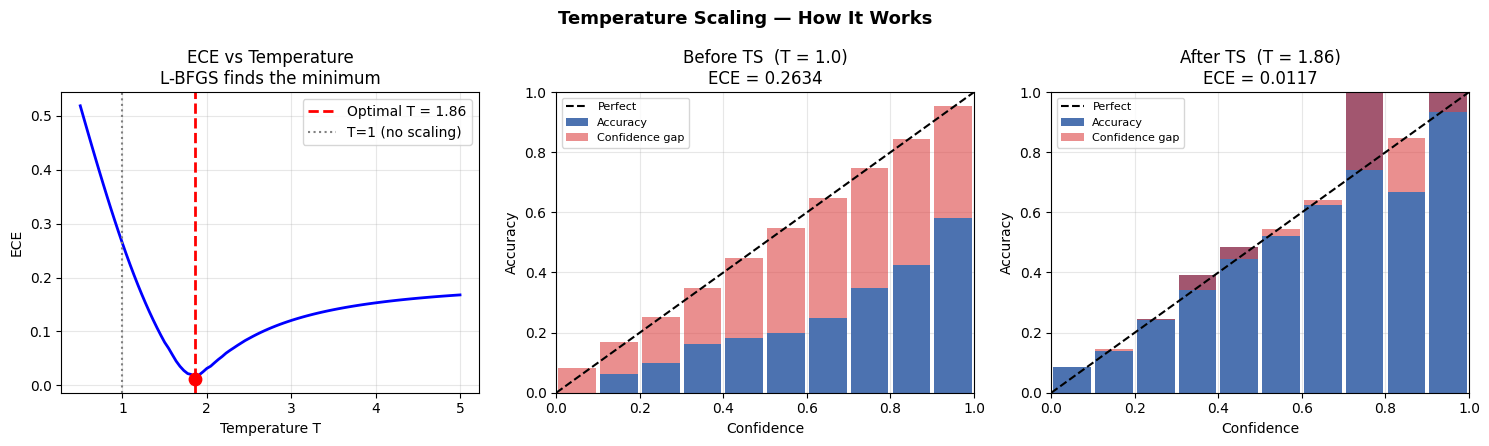

ECE before : 0.2634
ECE after  : 0.0117  (T = 1.86)


In [3]:

n = 2000
true_labels = np.random.randint(0, 100, n)
logits_sim  = np.random.randn(n, 100) * 3
logits_sim[np.arange(n), true_labels] += 5

n_bins    = 10
bin_edges = np.linspace(0, 1, n_bins+1)
centers   = (bin_edges[:-1]+bin_edges[1:])/2
W = bin_edges[1]-bin_edges[0]

def compute_ece(logits, labels):
    p = softmax(logits, axis=1)
    c, pred = p.max(1), p.argmax(1)
    acc = (pred==labels).astype(float)
    ece = 0
    for i in range(n_bins):
        m = (c>bin_edges[i])&(c<=bin_edges[i+1])
        if m.sum(): ece += m.sum()/len(labels)*abs(acc[m].mean()-c[m].mean())
    return ece

def bin_stats(logits, labels):
    p = softmax(logits, axis=1)
    c, pred = p.max(1), p.argmax(1)
    acc = (pred==labels).astype(float)
    ba, bc = [], []
    for i in range(n_bins):
        m = (c>bin_edges[i])&(c<=bin_edges[i+1])
        ba.append(acc[m].mean() if m.sum() else 0)
        bc.append(c[m].mean()   if m.sum() else centers[i])
    return np.array(bc), np.array(ba)

def reliability_diagram(ax, logits, labels, title):
    bc, ba = bin_stats(logits, labels)
    ax.bar(centers, ba, width=W*0.9, color='#4C72B0', label='Accuracy', zorder=2)
    ax.bar(centers, bc-ba, width=W*0.9, color='#DD4444', alpha=0.6,
           bottom=ba, label='Confidence gap', zorder=2)
    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect')
    ax.set(xlim=(0,1), ylim=(0,1), xlabel='Confidence', ylabel='Accuracy',
           title=f'{title}\nECE = {compute_ece(logits, labels):.4f}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

Ts   = np.linspace(0.5, 5.0, 100)
eces = [compute_ece(logits_sim/T, true_labels) for T in Ts]
best_T = Ts[np.argmin(eces)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Temperature Scaling — How It Works', fontsize=13, fontweight='bold')

axes[0].plot(Ts, eces, 'b-', lw=2)
axes[0].axvline(best_T, color='red', ls='--', lw=2, label=f'Optimal T = {best_T:.2f}')
axes[0].axvline(1.0, color='gray', ls=':', lw=1.5, label='T=1 (no scaling)')
axes[0].scatter([best_T],[min(eces)], color='red', s=80, zorder=5)
axes[0].set(xlabel='Temperature T', ylabel='ECE',
            title='ECE vs Temperature\nL-BFGS finds the minimum')
axes[0].legend(); axes[0].grid(alpha=0.3)

reliability_diagram(axes[1], logits_sim,          true_labels, 'Before TS  (T = 1.0)')
reliability_diagram(axes[2], logits_sim / best_T, true_labels, f'After TS  (T = {best_T:.2f})')

plt.tight_layout()
plt.show()

print(f"ECE before : {compute_ece(logits_sim, true_labels):.4f}")
print(f"ECE after  : {compute_ece(logits_sim/best_T, true_labels):.4f}  (T = {best_T:.2f})")


## 4. The central question — does TS hold under distribution shift?

Temperature scaling looks great on clean test data. But in practice, models are deployed on data that doesn't look exactly like the training distribution. A photo taken at night, a scan from a different machine, a sentence from a different domain — all of these represent **covariate shift**: the label distribution is the same, but the input distribution has changed.

Ovadia et al. (2019) were among the first to study calibration under shift systematically. Their finding was blunt: *traditional post-hoc calibration (TS) fails under shift*. Confidence stays high even as accuracy drops, because TS was fit on clean data and has no way of knowing the input is now corrupted.

But Ovadia was published in 2019, and the field has moved. Three methods in particular were designed specifically as lightweight alternatives that work under shift:

| Method | Year | Core idea |
|--------|------|-----------|
| **ETS** — Ensemble Temperature Scaling | 2020 | Mix TS output with raw softmax and a uniform prior; the uniform component prevents extreme overconfidence |
| **TvA** — Top-versus-All | 2024 | Treat calibration as $K$ binary problems instead of one multiclass problem; fits a separate logistic scaler per class |
| **DAC** — Density-Aware Calibration | 2023 | Adapt the temperature per sample based on how far it is from the training distribution in logit space |

None of these were benchmarked in the original Ovadia protocol. That's what we do here.

> **Scientific framing:** "Can modern post-hoc calibrators close the gap to ensemble methods at a fraction of the cost?" 


## 5. The model — DenseNet-BC-40 on CIFAR-100

Before we can calibrate anything we need a trained model. We use a **DenseNet-BC-40** with growth rate $k=12$, trained from scratch on CIFAR-100. The choice follows the original dataflowr repo and is a reasonable baseline: it's not state of the art, but it's strong enough to be overconfident (which is exactly what we want to study).

CIFAR-100 has 100 classes, 50,000 training images and 10,000 test images, all at 32×32 pixels. It's harder than CIFAR-10 and makes calibration more interesting because with 100 classes the model has more room to be confidently wrong.


### 5.1 DenseNet — why dense connections?

A standard ResNet adds a skip connection from layer $l$ to layer $l+1$:

$$x_{l+1} = F_l(x_l) + x_l$$

DenseNet takes this further: every layer receives the feature maps from **all** previous layers in the block:

$$x_l = H_l\bigl([x_0,\, x_1,\, \dots,\, x_{l-1}]\bigr)$$

where $[\cdot]$ is channel concatenation and $H_l$ is BN → ReLU → Conv. This means gradients flow directly from the loss to every layer, which makes training deep networks on small datasets like CIFAR more stable.

Each layer adds exactly $k$ new feature maps ( $k$ is called the **growth rate**). With $k=12$, a layer that receives input with $c$ channels outputs a tensor with $c+12$ channels. The feature maps accumulate as you go deeper.

The **BC** (Bottleneck + Compression) variant adds two tricks to keep the model small:
- **Bottleneck**: a $1\times1$ conv before every $3\times3$ conv to reduce channels to $4k$ first
- **Compression**: transition layers between blocks halve the number of channels

The result is a network that is deep but parameter-efficient: DenseNet-40 has far fewer parameters than a comparable ResNet.


### 5.2 Inside a dense block

Each layer $H_l$ in the BC variant has this structure:

$$\text{BN} \to \text{ReLU} \to \text{Conv}_{1\times1}(4k) \to \text{BN} \to \text{ReLU} \to \text{Conv}_{3\times3}(k)$$

The $1\times1$ conv is the bottleneck: it projects the concatenated input (which grows with depth) down to $4k=48$ channels, keeping the $3\times3$ conv cheap regardless of how deep we are.

For our DenseNet-40 with $k=12$:
- **Block config**: depth 40 → $(40 - 4) / 6 = 6$ layers per block
- **3 blocks** of 6 layers each, separated by 2 transition layers
- **Total parameters**: ~1M — much smaller than ResNet-110 (~1.7M) on the same task

The `-4` accounts for the initial conv layer + the final classifier layer + 2 transition layers, and the `/6` comes from splitting equally across 3 blocks with the BC bottleneck counting as one composite layer.


## 6. Training (`train.py`)

The training script follows the standard recipe from the DenseNet paper. A few decisions are worth calling out explicitly because they matter for calibration downstream.

**Optimiser:** SGD with Nesterov momentum. Nesterov is a small tweak: instead of computing the gradient at the current position, it computes it one step ahead in the momentum direction. It tends to converge slightly faster and is the standard choice for CIFAR training.

**Learning rate schedule:** cosine-ish step decay. We start at $\eta_0 = 0.1$ and drop by $\times 0.1$ at epoch 150 and epoch 225 (i.e. at 50% and 75% of total training). The sharp drops correspond to the loss landscape flattening out — the model has found a good basin and needs a smaller step to settle into it.

**The validation split:** this is the most important design decision for calibration. We randomly hold out 5,000 samples from the 50,000 training set. These are *never* used for training. The model checkpoint and the indices of this split are both saved so that later, when we run temperature scaling, we fit $T$ on exactly the same 5,000 samples. If we re-split randomly we'd get a different $T$, and the comparison would be noisy.

$$\mathcal{L}_{\text{train}} = -\frac{1}{n}\sum_{i=1}^{n} \log \frac{e^{z_{y_i}}}{\sum_j e^{z_j}} = \text{cross-entropy}$$


### 6.1 Why does the trained model end up overconfident?

This is worth understanding because it explains *why* we need calibration in the first place.

Cross-entropy loss pushes the model to assign probability 1 to the correct class and 0 to everything else. With enough capacity and enough epochs, the model gets very good at this on the training set. The problem is that it generalises this sharpness to the test set: it outputs high-confidence predictions everywhere, even in regions of input space it has never seen.

Two factors make this worse in practice:
1. **Weight decay** shrinks weights but not the bias toward high confidence: the logit magnitude grows during training because large logits are rewarded by cross-entropy
2. **Batch normalisation** keeps activations well-scaled during training, but at test time the running statistics may not perfectly match, slightly shifting the logit distribution

The net effect: after 300 epochs of training, the model confidently assigns ~90%+ probability to its top prediction on most inputs. On the clean test set this is partially justified by high accuracy. Under corruption it becomes a problem: accuracy drops but confidence doesn't, and ECE grows.


## 7. From training to calibration

Once `train.py` finishes, we have two files in `checkpoints/`:

- `model.pth` — the state dict of the best checkpoint (lowest validation error)
- `valid_indices.pth` — the exact 5,000 indices held out from training

The model at this point is uncalibrated. `demo.py` loads these two files, reconstructs the validation loader using the same indices, and runs `set_temperature()` — which collects logits on the validation set and runs L-BFGS to find the optimal $T$.

The reason we need to save the indices rather than re-splitting is that if we created a new random split, some of the "validation" samples might have been in the training set originally. That would leak training data into the calibration fitting and bias $T$ downward (model performs better on training data → lower NLL → lower $T$ than we'd get on truly held-out data).




## 8. Post-Hoc Calibration Methods



### 8.1 Temperature Scaling (Guo et al. 2017)

The simplest possible calibrator. One scalar $T$, one optimization, done.

$$p_k = \frac{\exp(z_k / T)}{\displaystyle\sum_{j=1}^{K} \exp(z_j / T)}$$

$T$ is found by minimizing NLL on the validation set:

$$T^* = \arg\min_{T > 0} \; -\frac{1}{n}\sum_{i=1}^{n} \log p_{y_i}(z_i / T)$$

This is a one-dimensional convex optimization problem — there's a unique global minimum and L-BFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) finds it in a handful of steps.

**Why it works on clean data:** the model is uniformly overconfident across all classes and inputs. A single global rescaling fixes this well when the overconfidence is roughly constant.

**Why it fails under shift:** when the image is corrupted, the model becomes *more* overconfident in specific ways that vary by corruption type and severity. A single global $T$ can't track this (it was fit on clean data and stays fixed at test time regardless of how corrupted the input is).



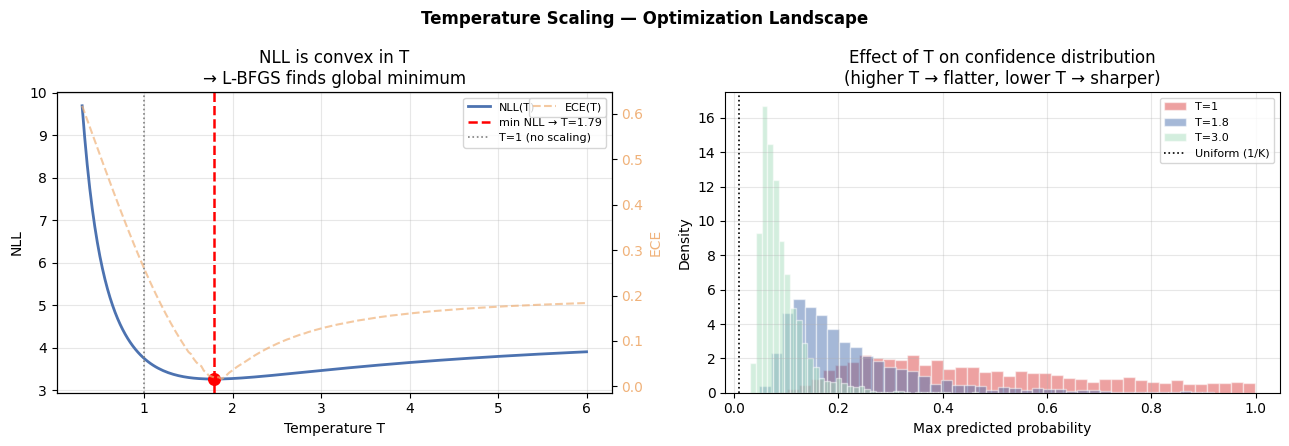

T* (minimising NLL): 1.789
NLL before: 3.7513  →  after: 3.2643
ECE before: 0.2599  →  after: 0.0198


In [4]:


np.random.seed(0)
n = 3000
labels = np.random.randint(0, 100, n)
logits = np.random.randn(n, 100) * 3
logits[np.arange(n), labels] += 5

def nll(logits, labels):
    p = softmax(logits, axis=1)
    return -np.log(p[np.arange(len(labels)), labels] + 1e-12).mean()

def ece(logits, labels, n_bins=15):
    p = softmax(logits, axis=1)
    c, pred = p.max(1), p.argmax(1)
    acc = (pred==labels).astype(float)
    edges = np.linspace(0,1,n_bins+1)
    out = 0
    for i in range(n_bins):
        m = (c>edges[i])&(c<=edges[i+1])
        if m.sum(): out += m.sum()/len(labels)*abs(acc[m].mean()-c[m].mean())
    return out

Ts = np.linspace(0.3, 6.0, 200)
nlls = [nll(logits/T, labels) for T in Ts]
eces = [ece(logits/T, labels) for T in Ts]

best_T_nll = Ts[np.argmin(nlls)]
best_T_ece = Ts[np.argmin(eces)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Temperature Scaling — Optimization Landscape', fontsize=12, fontweight='bold')

axes[0].plot(Ts, nlls, color='#4C72B0', lw=2, label='NLL(T)')
axes[0].axvline(best_T_nll, color='red', ls='--', lw=1.8, label=f'min NLL → T={best_T_nll:.2f}')
axes[0].axvline(1.0, color='gray', ls=':', lw=1.2, label='T=1 (no scaling)')
axes[0].scatter([best_T_nll],[min(nlls)], color='red', s=70, zorder=5)
axes[0].set(xlabel='Temperature T', ylabel='NLL',
            title='NLL is convex in T\n→ L-BFGS finds global minimum')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

ax2 = axes[0].twinx()
ax2.plot(Ts, eces, color='#F0B27A', lw=1.5, ls='--', alpha=0.7, label='ECE(T)')
ax2.set_ylabel('ECE', color='#F0B27A')
ax2.tick_params(axis='y', labelcolor='#F0B27A')
ax2.legend(loc='upper right', fontsize=8)

# show effect on confidence distribution
for T_val, color, label in [(1.0,'#DD4444','T=1'), (best_T_nll,'#4C72B0',f'T={best_T_nll:.1f}'), (3.0,'#A9DFBF','T=3.0')]:
    p = softmax(logits/T_val, axis=1)
    axes[1].hist(p.max(1), bins=40, alpha=0.5, color=color,
                 label=label, density=True, edgecolor='white')

axes[1].axvline(1/100, color='black', ls=':', lw=1.2, label='Uniform (1/K)')
axes[1].set(xlabel='Max predicted probability', ylabel='Density',
            title='Effect of T on confidence distribution\n(higher T → flatter, lower T → sharper)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"T* (minimising NLL): {best_T_nll:.3f}")
print(f"NLL before: {nll(logits, labels):.4f}  →  after: {nll(logits/best_T_nll, labels):.4f}")
print(f"ECE before: {ece(logits, labels):.4f}  →  after: {ece(logits/best_T_nll, labels):.4f}")


### 8.2 Ensemble Temperature Scaling — Zhang et al. (2020)

ETS asks: what if instead of committing to a single softmax output, we hedge between three different "views" of the logits?

$$p = w_1 \cdot \underbrace{\text{softmax}(z/T)}_{\text{scaled}} \;+\; w_2 \cdot \underbrace{\text{softmax}(z)}_{\text{original}} \;+\; w_3 \cdot \underbrace{\frac{\mathbf{1}}{K}}_{\text{uniform}}$$

with $w_1 + w_2 + w_3 = 1$, $w_i \geq 0$, and both $T$ and the weights jointly optimised on the validation set.

The three components play distinct roles:
- $w_1$ — the standard TS component, does the heavy lifting on clean data
- $w_2$ — preserves the original confidence ranking when the model is already well-ordered
- $w_3$ — the uniform prior acts as a regulariser. When the model is deeply uncertain (high corruption), this component pulls confidence toward $1/K$, preventing extreme overconfidence

In practice $w_3$ tends to be small on clean data but becomes important under shift. The model can't directly detect shift at test time, but the ensemble mixture provides a softer output that degrades more gracefully than a hard TS.

Note that ETS also preserves accuracy when $w_3 = 0$ (the argmax doesn't change). With a non-zero uniform component the argmax can theoretically change, but in practice the effect is negligible since the uniform term is small.


### 8.3 Top-versus-All (Paisley et al. 2024)

TvA is conceptually the cleanest of the four methods. It asks: instead of calibrating a 100-class probability vector as a whole, what if we treat each class independently as a binary problem?

For each class $k$, we learn a logistic regression on the raw logit $z_k$:

$$q_k = \sigma(a_k \cdot z_k + b_k) = \frac{1}{1 + e^{-(a_k z_k + b_k)}}$$

This gives us $K$ independent binary probabilities — the probability that class $k$ is the correct answer in a one-vs-rest sense. We then normalise to get a valid probability vector:

$$p_k = \frac{q_k}{\sum_{j=1}^{K} q_j}$$

Two learnable parameters per class: $a_k$ scales the logit (like a per-class temperature) and $b_k$ shifts the threshold. So TvA has $2K = 200$ parameters for CIFAR-100 vs TS's single $T$.

**Why this matters:** TS applies the same correction to every class. But miscalibration isn't uniform: some classes the model is systematically overconfident about (visually similar classes), others it's underconfident about. TvA can correct class-specific biases that TS can't see.

**The fitting:** all $2K$ parameters are optimised jointly with binary cross-entropy, which makes the problem separable per class and fast to solve.


### 8.4 Density-Aware Calibration (2023)

DAC is the most sophisticated of the four. The key observation is that TS applies a **fixed** $T$ to every input regardless of how unusual it is. An image with mild Gaussian noise and an image with extreme fog both get divided by the same temperature. This is clearly suboptimal — the foggy image is far more uncertain and deserves a higher temperature.

DAC makes the temperature **input-dependent**:

$$T(x) = \text{softplus}\!\left(T_{\text{base}} + \alpha \cdot d(x)\right)$$

where $d(x)$ measures how far the input's logit vector is from the training distribution:

$$d(x) = \left\| \frac{z(x) - \mu_{\text{val}}}{\sigma_{\text{val}}} \right\|_2$$

$\mu_{\text{val}}$ and $\sigma_{\text{val}}$ are the mean and standard deviation of the logit vectors on the validation set, computed once during fitting. At test time, $d(x)$ is computed for each input and plugged into the formula above.

The $\text{softplus}(u) = \log(1 + e^u)$ ensures $T(x) > 0$ always. The parameter $\alpha \geq 0$ controls sensitivity to OOD-ness — if $\alpha = 0$ we recover standard TS.

**Intuition:** a clean in-distribution image lands close to $\mu_{\text{val}}$ in logit space, so $d(x)$ is small and $T(x) \approx T_{\text{base}}$. A heavily corrupted image produces unusual logits, $d(x)$ is large, and $T(x)$ grows automatically (the model becomes less confident without any explicit OOD detector).

**The fitting:** $T_{\text{base}}$ and $\alpha$ are jointly optimised with NLL on the validation set using L-BFGS. Only two parameters, but they encode something qualitatively richer than TS.


### 8.5 Comparing the four methods — what each one can and can't do

It helps to think about what each method is actually doing to the output distribution:

**TS** applies a global softening. Every single prediction gets divided by the same $T$. If the average overconfidence is 15%, TS fixes the average, but for any individual prediction the correction could be too strong or too weak. It has no way of knowing.

**ETS** adds two safety valves. The raw softmax component means that if the model happens to be well-calibrated already, the correction doesn't overshoot. The uniform component means that even in the worst case, the output can't become infinitely overconfident.

**TvA** breaks the problem along the class axis. It can handle the fact that the model is overconfident about "dogs" but underconfident about "lizards". TS treats all 100 classes identically. The cost is 200 parameters instead of 1, but the fitting is still fast since the binary problems are independent.

**DAC** breaks the problem along the sample axis. Instead of treating all test inputs identically (like TS does), it adjusts the temperature per input based on how unusual that input is. This is the right inductive bias for corruption shift — corrupted images are by definition unusual, so they should automatically get higher uncertainty.

None of them is strictly better in all situations. The interesting question ( which we answer empirically)  is which one degrades most gracefully as corruption severity increases.


## 9. The Ovadia++ Benchmark

The benchmark loop implemented in `evaluate_shift.py` proceeds as follows:

- For each method in **[TS, ETS, TvA, DAC]**:  
  - Fit the calibrator on a clean validation set (5,000 samples).  
  - Evaluate on the clean test set to obtain a baseline.  
  - For each of the 13 corruption types:  
    - For each severity level:  
      - Apply the corruption on-the-fly.  
      - Evaluate and record **Accuracy, NLL, ECE, and AdaECE**.  

All results are stored in a single file, `ovadia_plus_results.json`, so the expensive evaluation never needs to be rerun. Every analysis cell below simply loads and reads from this file.

### 9.1 The corruption taxonomy

We use 13 corruption types split across 4 categories. Each runs at 5 severity levels  (severity 1 is barely noticeable, severity 5 is severe degradation). The corruptions are applied **on-the-fly** by `CorruptedDataset`, which wraps the standard CIFAR-100 test set and intercepts `__getitem__`.

The categories are chosen to represent different failure modes a deployed model might encounter:

- **Noise** — sensor noise, shot noise in low-light, impulse noise from bit errors
- **Blur** — focus issues, motion, zoom artefacts, glass refraction
- **Weather** — fog, overexposure (brightness), underexposure (contrast)
- **Digital** — elastic deformation, pixelation (low-res), JPEG compression artefacts

What makes this interesting is that different calibrators respond differently to different corruption types. A method that handles noise well might struggle with blur. The per-corruption breakdown is where the real differences between methods emerge.


### 9.2 Clean baseline — calibration on in-distribution data

Before looking at shift, we check that all four methods do what they're supposed to on clean CIFAR-100. A calibrator that doesn't work on clean data is not worth testing under shift. The numbers here also give us a reference point — we'll see how much each metric degrades as severity increases.

One thing to note: accuracy should be identical across TS and ETS (since the argmax doesn't change under pure temperature scaling). TvA and DAC may show marginal differences because their corrections are not strictly rank-preserving.


In [5]:
CHECKPOINT_DIR = './checkpoints'

with open(os.path.join(CHECKPOINT_DIR, 'ovadia_plus_results.json')) as f:
    results = json.load(f)

METHODS     = list(results.keys())
CORRUPTIONS = list(results[METHODS[0]]['corruptions'].keys())
SEVERITIES  = [1, 2, 3, 4, 5]

COLORS  = {'ts':'#2196F3', 'ets':'#4CAF50', 'tva':'#FF9800', 'dac':'#9C27B0'}
MARKERS = {'ts':'o', 'ets':'s', 'tva':'^', 'dac':'D'}
CATS = {
    'Noise'  : ['gaussian_noise','shot_noise','impulse_noise'],
    'Blur'   : ['defocus_blur','glass_blur','motion_blur','zoom_blur'],
    'Weather': ['fog','brightness','contrast'],
    'Digital': ['elastic_transform','pixelate','jpeg_compression'],
}

print(f"Methods     : {[m.upper() for m in METHODS]}")
print(f"Corruptions : {len(CORRUPTIONS)}")
print(f"Severities  : {SEVERITIES}")


rows = []
for m in METHODS:
    cb = results[m]['clean_baseline']
    rows.append({
        'Method'  : m.upper(),
        'Accuracy': round(cb['accuracy'], 4),
        'NLL'     : round(cb['nll'],      4),
        'ECE'     : round(cb['ece'],      4),
        'AdaECE'  : round(cb['adaptive_ece'], 4),
    })

df_clean = pd.DataFrame(rows).set_index('Method')
print("=== Clean CIFAR-100 Test Set ===")
display(df_clean)


Methods     : ['TS', 'ETS', 'TVA', 'DAC']
Corruptions : 13
Severities  : [1, 2, 3, 4, 5]
=== Clean CIFAR-100 Test Set ===


,Accuracy,NLL,ECE,AdaECE
Method,,,,
TS,0.6533,1.4428,0.1347,0.1347
ETS,0.6533,1.3665,0.0658,0.0657
TVA,0.4988,3.7879,0.4742,0.4742
DAC,0.6533,1.3449,0.1010,0.1010


### 9.3 Under distribution shift — the main experiment

Now we look at what happens as we move away from the training distribution. For each method we track ECE and accuracy across all 13 corruptions and all 5 severities.

Two questions drive the analysis:

1. **Does ECE grow faster than accuracy drops?** If yes, the model becomes miscalibrated before it becomes inaccurate — meaning users would be misled by high confidence on wrong predictions before they even notice the accuracy drop.

2. **Which method degrades most gracefully?** We want a calibrator whose ECE stays low even at severity 5, ideally without sacrificing accuracy.

The next cells show the results at three levels of granularity: aggregate (all corruptions averaged), per corruption category, and per individual corruption.


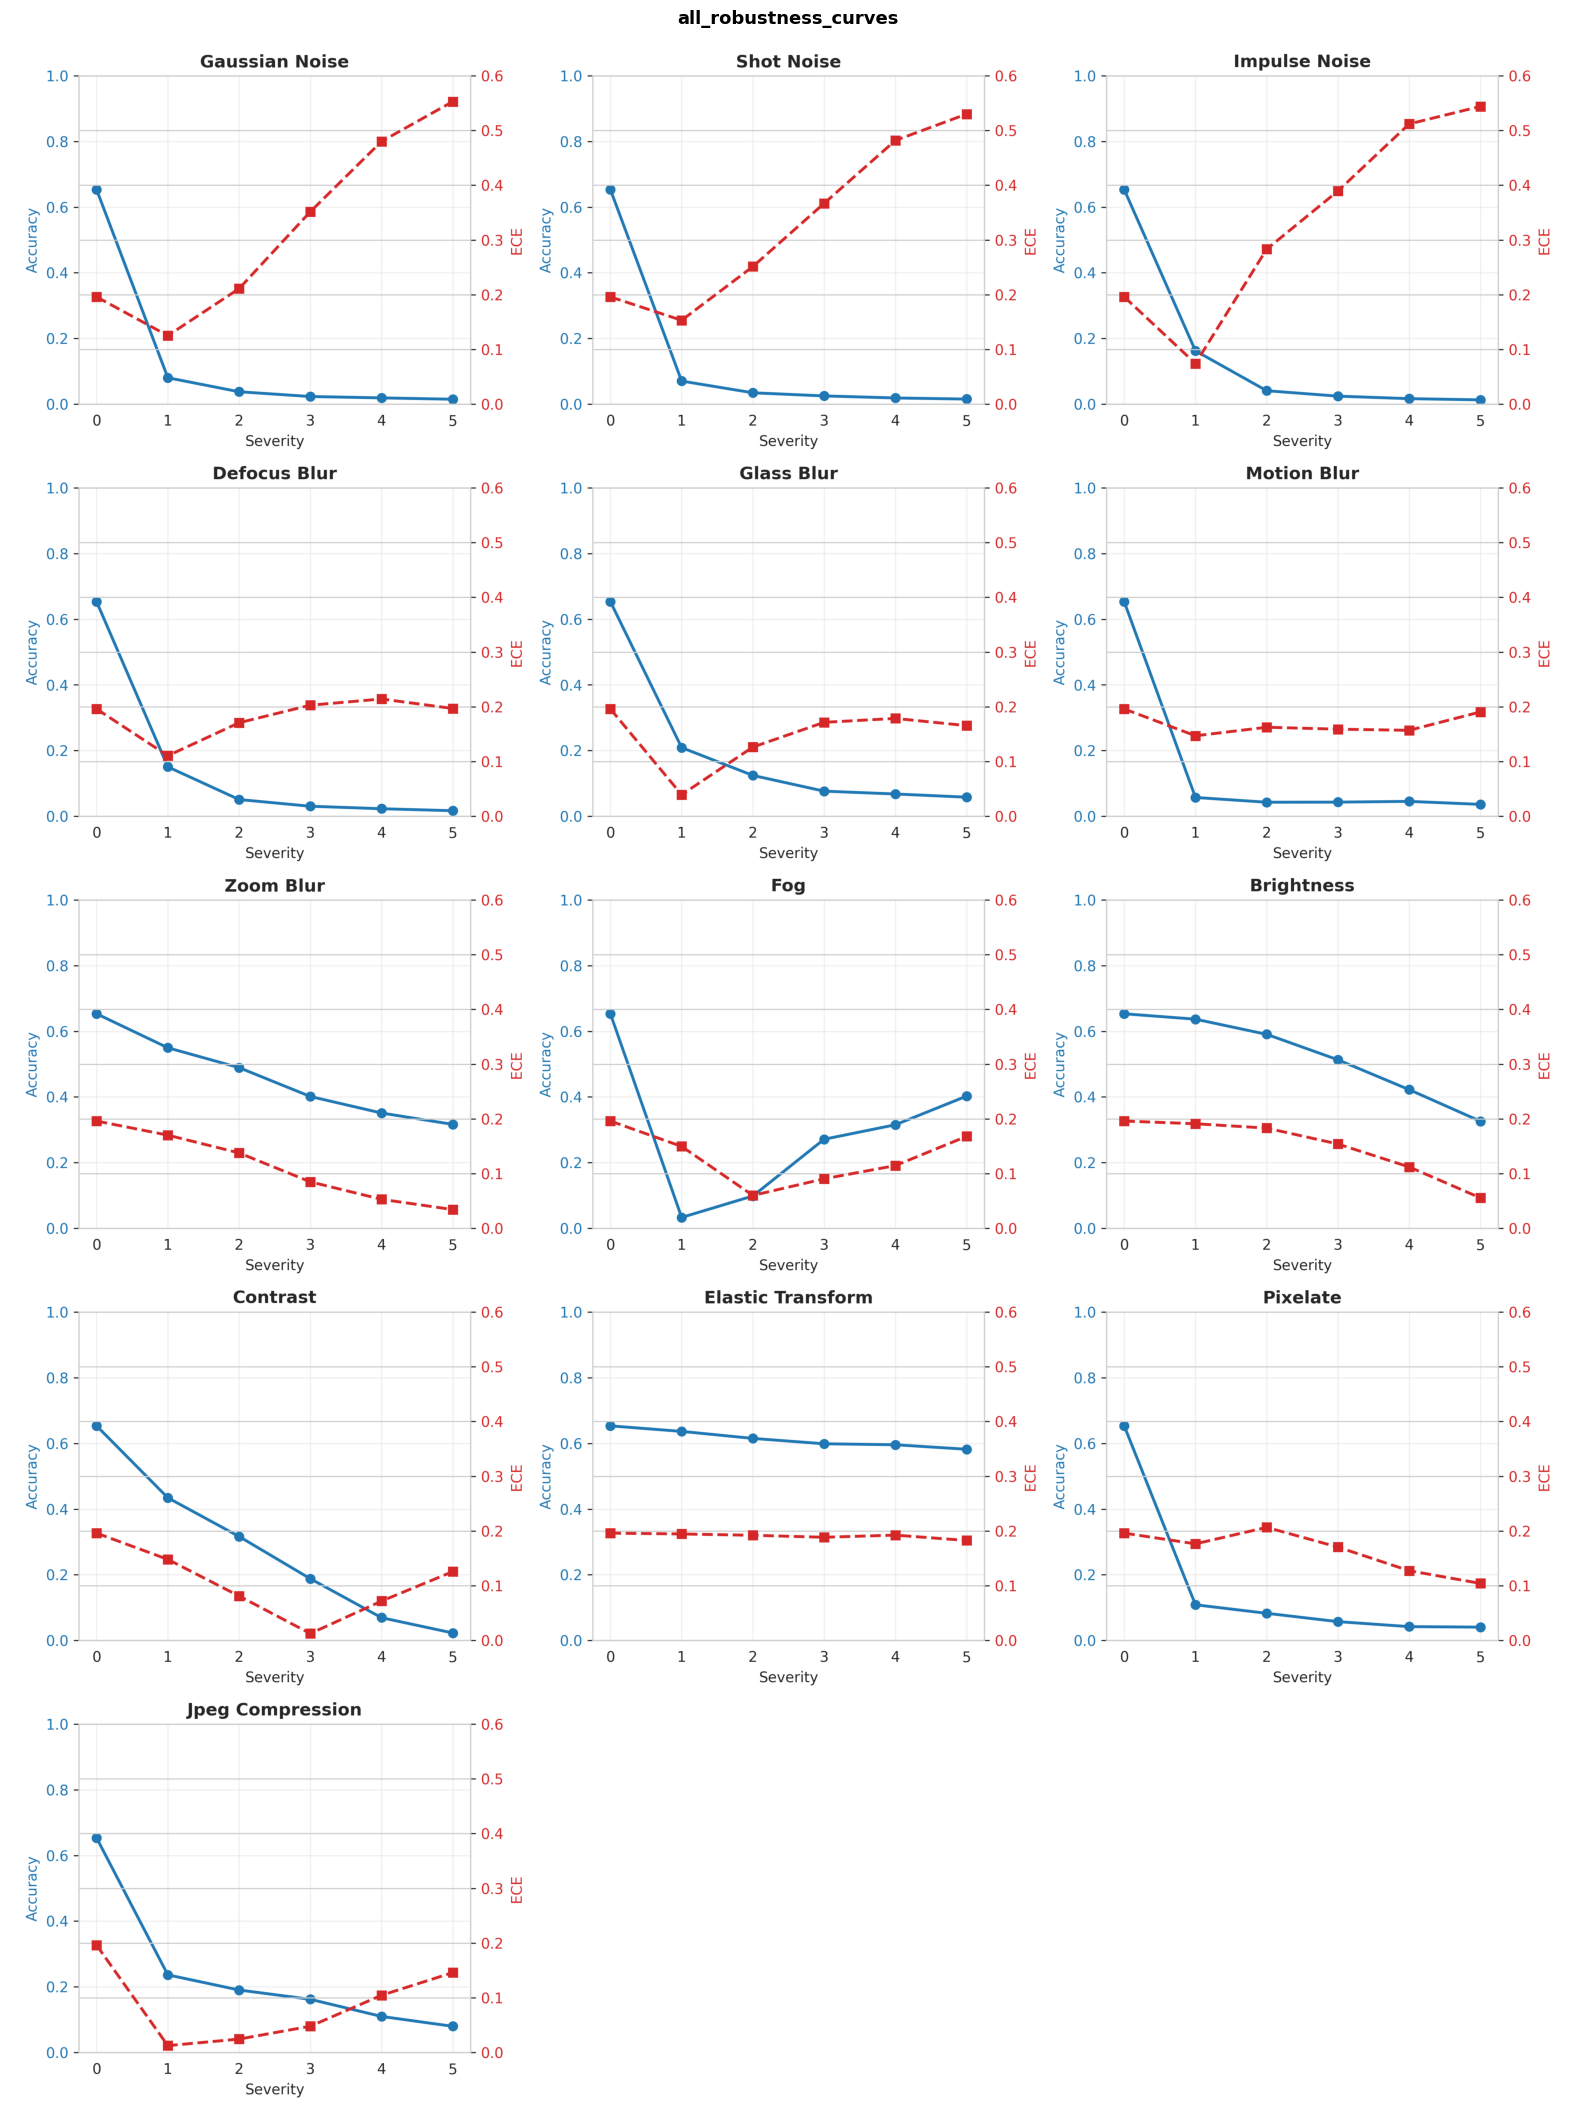

In [6]:
# Display the plots already generated by your plotting scripts
plot_registry = {
    'All Robustness Curves'  : 'all_robustness_curves.png',
}
title,fname= 'all_robustness_curves', 'all_robustness_curves.png'

fpath = os.path.join(CHECKPOINT_DIR, fname)

img = mpimg.imread(fpath)
h, w = img.shape[:2]
fig, ax = plt.subplots(figsize=(16, 16*h/w))
ax.imshow(img); ax.axis('off')
ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
plt.tight_layout(); plt.show()


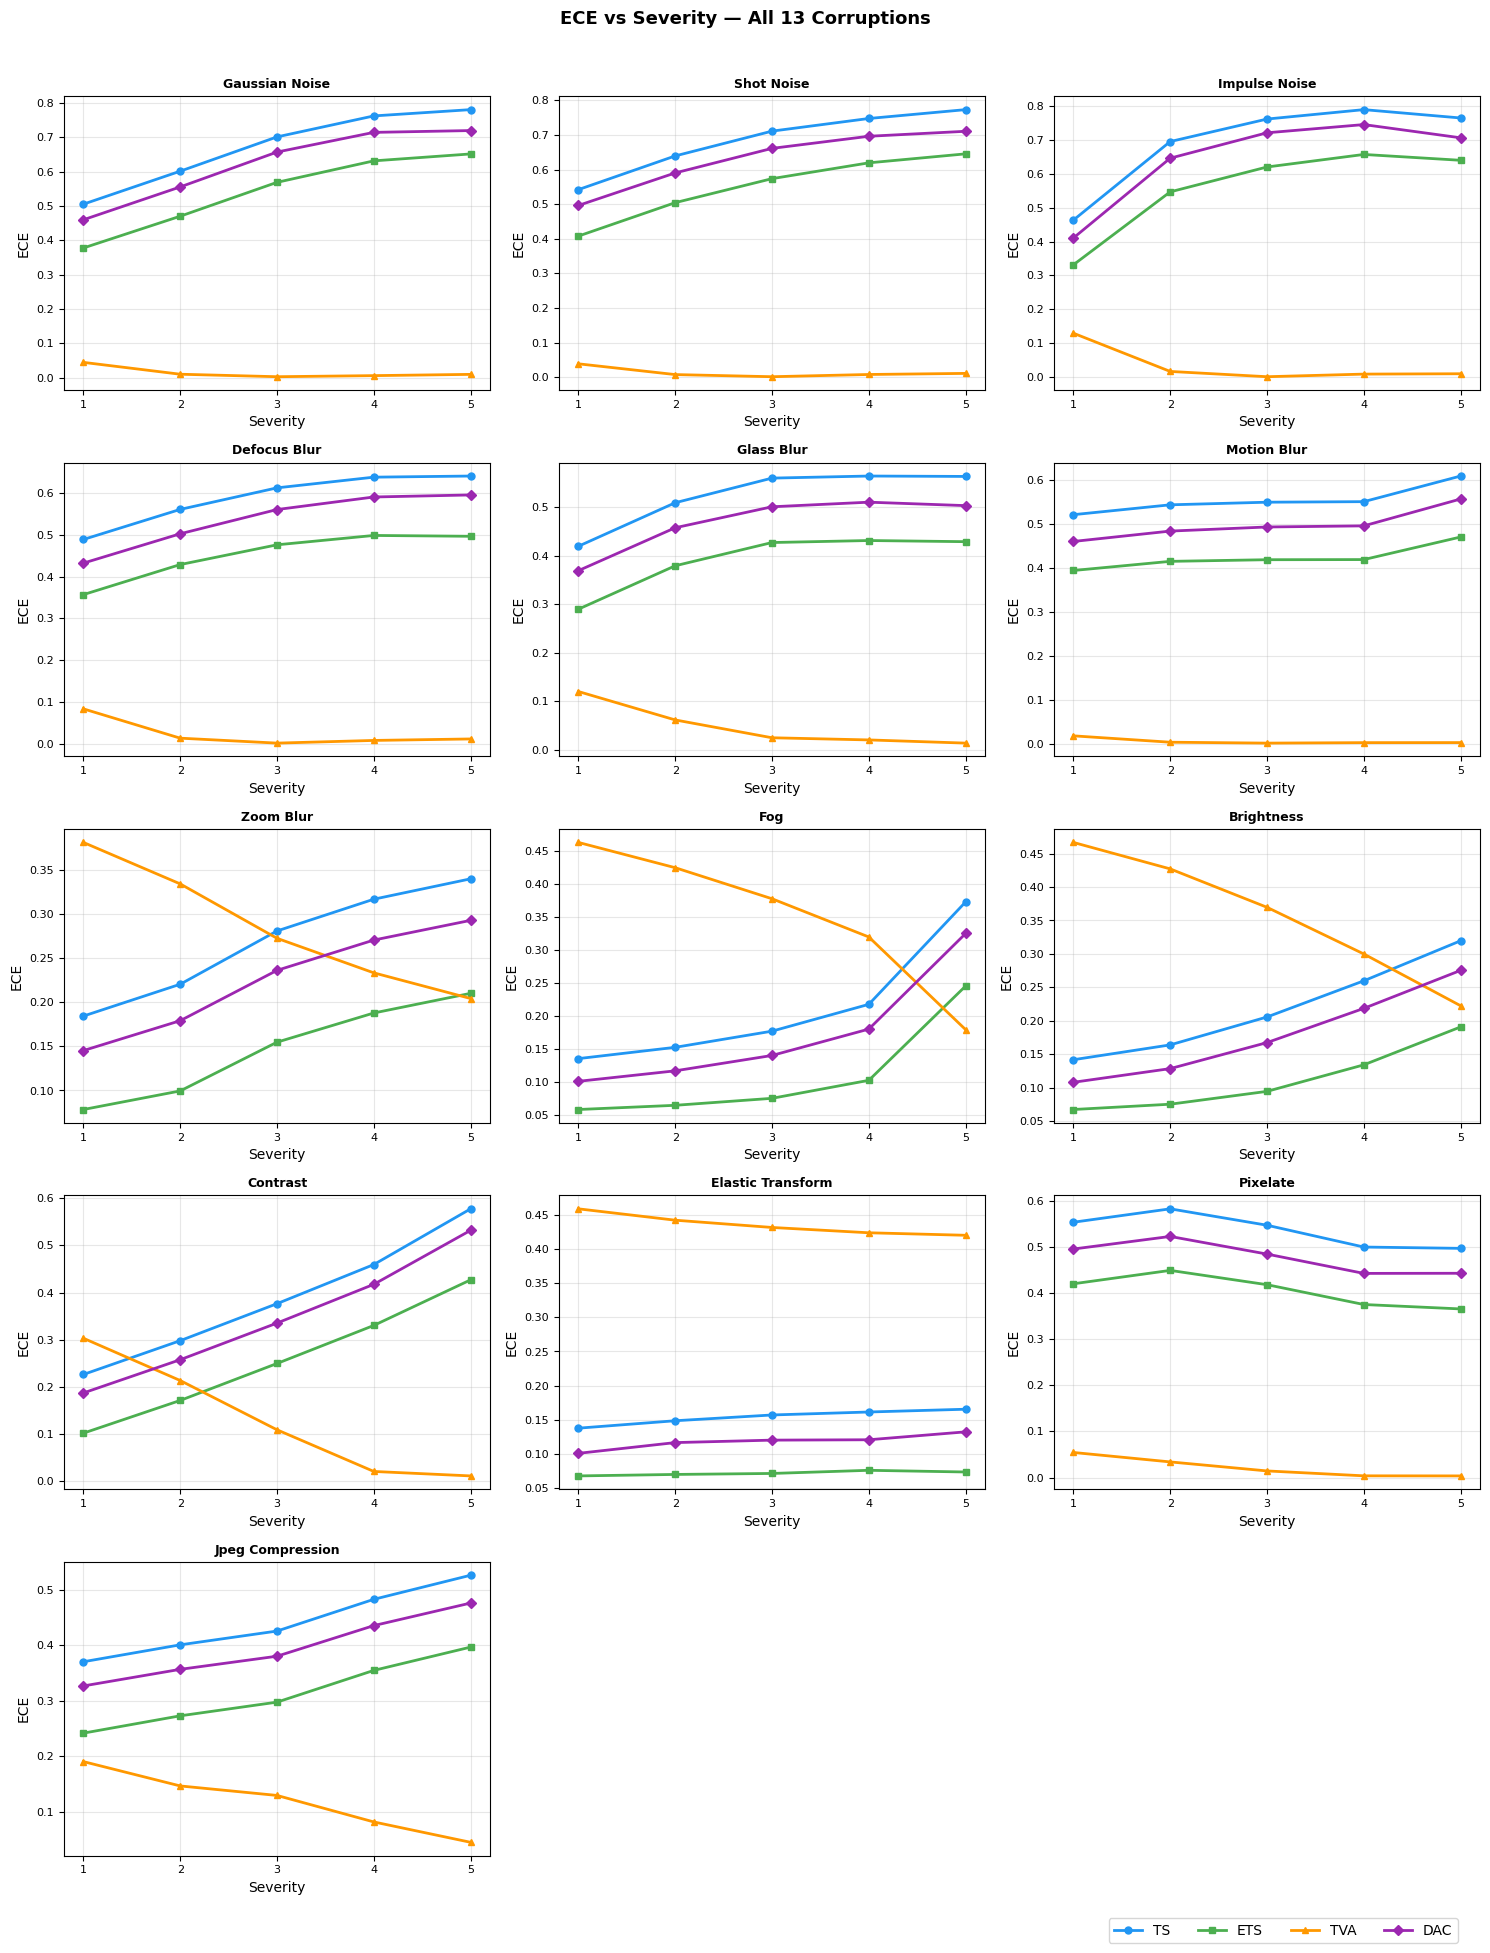

In [7]:
n_cols = 3
n_rows = math.ceil(len(CORRUPTIONS) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows), sharey=False)
fig.suptitle('ECE vs Severity — All 13 Corruptions', fontsize=13, fontweight='bold')

for i, corr in enumerate(CORRUPTIONS):
    ax = axes.flat[i]
    for m in METHODS:
        eces = [results[m]['corruptions'][corr][str(s)]['ece'] for s in SEVERITIES]
        ax.plot(SEVERITIES, eces, marker=MARKERS[m], color=COLORS[m],
                lw=2, ms=5, label=m.upper())
    ax.set_title(corr.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.set_xticks(SEVERITIES)
    ax.set(xlabel='Severity', ylabel='ECE')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

for j in range(len(CORRUPTIONS), len(axes.flat)):
    axes.flat[j].set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right',
           fontsize=10, ncol=len(METHODS), bbox_to_anchor=(0.98, 0.01))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


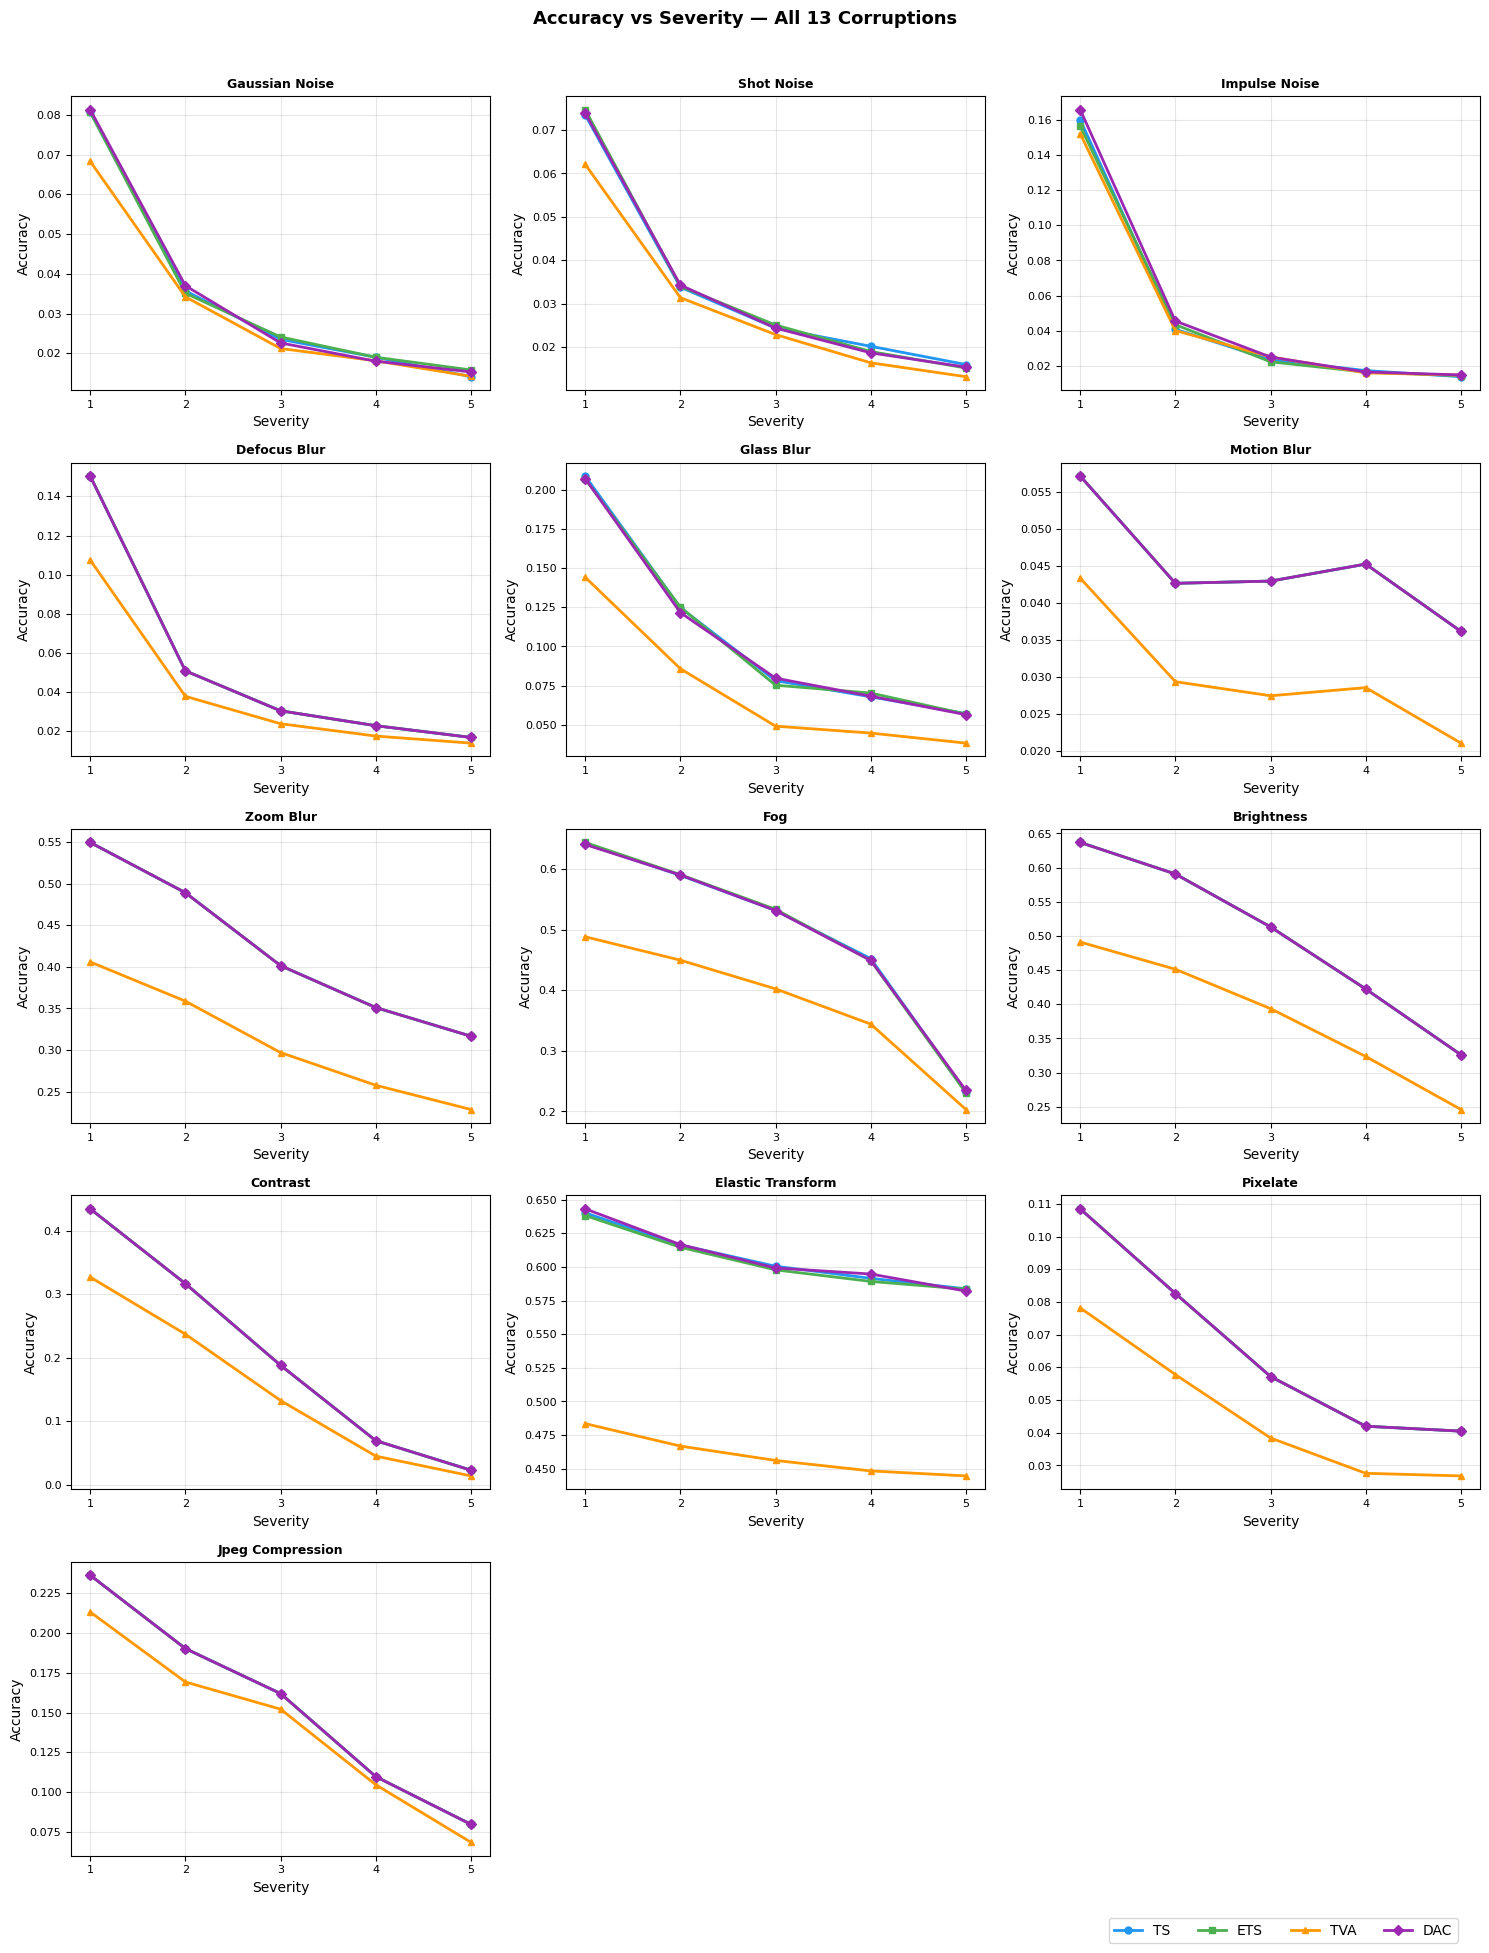

In [8]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows), sharey=False)
fig.suptitle('Accuracy vs Severity — All 13 Corruptions', fontsize=13, fontweight='bold')

for i, corr in enumerate(CORRUPTIONS):
    ax = axes.flat[i]
    for m in METHODS:
        accs = [results[m]['corruptions'][corr][str(s)]['accuracy'] for s in SEVERITIES]
        ax.plot(SEVERITIES, accs, marker=MARKERS[m], color=COLORS[m],
                lw=2, ms=5, label=m.upper())
    ax.set_title(corr.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.set_xticks(SEVERITIES)
    ax.set(xlabel='Severity', ylabel='Accuracy')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

for j in range(len(CORRUPTIONS), len(axes.flat)):
    axes.flat[j].set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right',
           fontsize=10, ncol=len(METHODS), bbox_to_anchor=(0.98, 0.01))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


NameError: name 'METHOD_LABELS' is not defined

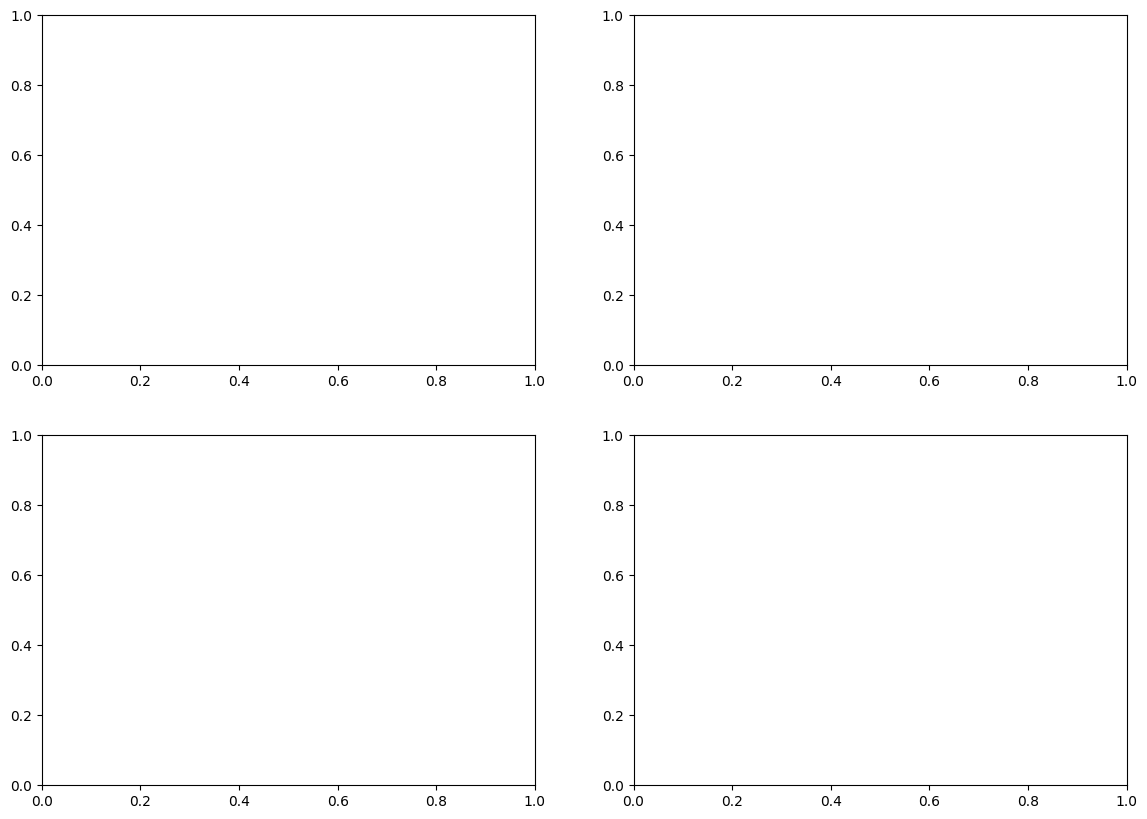

In [9]:
import numpy as np
import matplotlib.pyplot as plt

SEVERITIES   = [1, 2, 3, 4, 5]
METRICS      = ['nll', 'accuracy', 'ece', 'adaptive_ece']
METRIC_LABELS = {
    'nll':          'Negative Log-Likelihood (NLL)',
    'accuracy':     'Top-1 Accuracy',
    'ece':          'Expected Calibration Error (ECE)',
    'adaptive_ece': 'Adaptive ECE',
}
METRIC_ARROW = {          # True = lower is better
    'nll':          '↓ lower is better',
    'accuracy':     '↑ higher is better',
    'ece':          '↓ lower is better',
    'adaptive_ece': '↓ lower is better',
}

# ── Aggregate: mean over all corruptions per (method, severity) ──────────────
def mean_over_corruptions(method_key, metric):
    """Returns array of shape (5,) — one value per severity."""
    return np.array([
        np.mean([
            results[method_key]['corruptions'][c][str(s)][metric]
            for c in CORRUPTIONS
        ])
        for s in SEVERITIES
    ])

# ── Pre-compute all curves ────────────────────────────────────────────────────
curves = {
    m: {metric: mean_over_corruptions(m, metric) for metric in METRICS}
    for m in METHODS
}

# ── Clean baseline horizontal reference lines ─────────────────────────────────
clean_vals = {
    m: {metric: results[m]['clean_baseline'][metric] for metric in METRICS}
    for m in METHODS
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, METRICS):
    for m in METHODS:
        lbl = METHOD_LABELS[m]
        ax.plot(SEVERITIES, curves[m][metric],
                marker='o', lw=2.2, ms=6,
                color=COLORS[m], label=lbl)
       

    ax.set_title(METRIC_LABELS[metric], fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Corruption Severity', fontsize=10)
    ax.set_ylabel(f"{METRIC_LABELS[metric].split('(')[-1].rstrip(')')}"
                  if '(' in METRIC_LABELS[metric]
                  else METRIC_LABELS[metric],
                  fontsize=10)
    ax.set_xticks(SEVERITIES)
    ax.text(0.98, 0.97, METRIC_ARROW[metric],
            transform=ax.transAxes, fontsize=8, color='gray',
            ha='right', va='top', style='italic')
    ax.grid(alpha=0.25, linestyle=':')
    ax.spines[['top', 'right']].set_visible(False)



fig.suptitle(
    'Calibration Metrics vs. Corruption Severity on CIFAR-100\n'
    'Mean over all 13 corruption types' ,
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('checkpoints/TS curves under corruption.png',
            dpi=150, bbox_inches='tight')
plt.show()


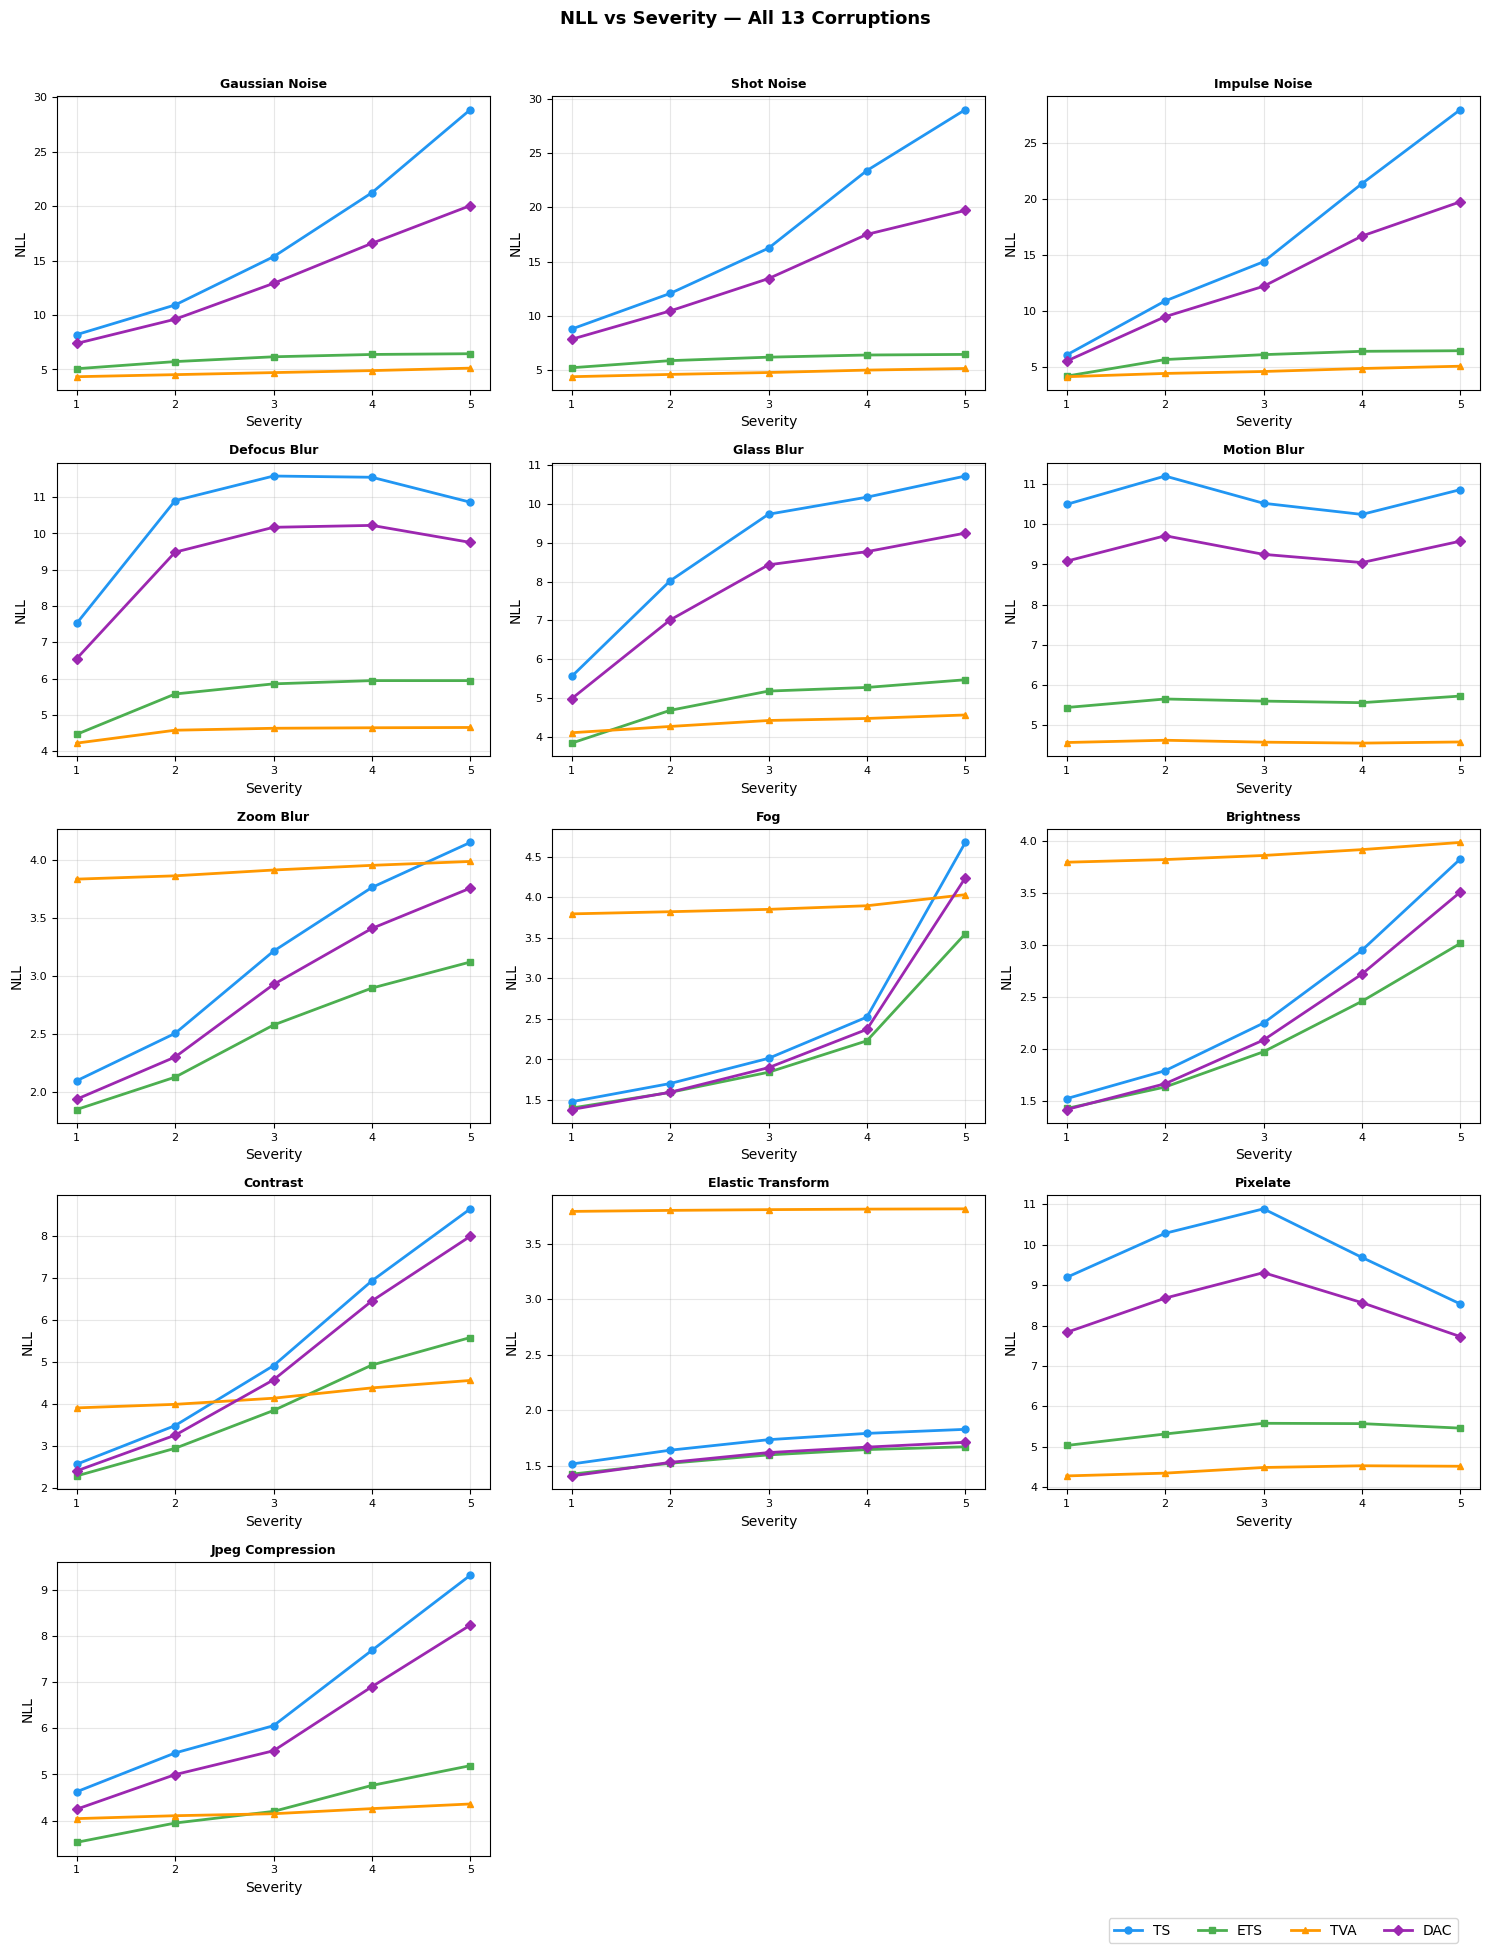

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows), sharey=False)
fig.suptitle('NLL vs Severity — All 13 Corruptions', fontsize=13, fontweight='bold')

for i, corr in enumerate(CORRUPTIONS):
    ax = axes.flat[i]
    for m in METHODS:
        nlls = [results[m]['corruptions'][corr][str(s)]['nll'] for s in SEVERITIES]
        ax.plot(SEVERITIES, nlls, marker=MARKERS[m], color=COLORS[m],
                lw=2, ms=5, label=m.upper())
    ax.set_title(corr.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.set_xticks(SEVERITIES)
    ax.set(xlabel='Severity', ylabel='NLL')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

for j in range(len(CORRUPTIONS), len(axes.flat)):
    axes.flat[j].set_visible(False)

handles, labels_leg = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower right',
           fontsize=10, ncol=len(METHODS), bbox_to_anchor=(0.98, 0.01))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


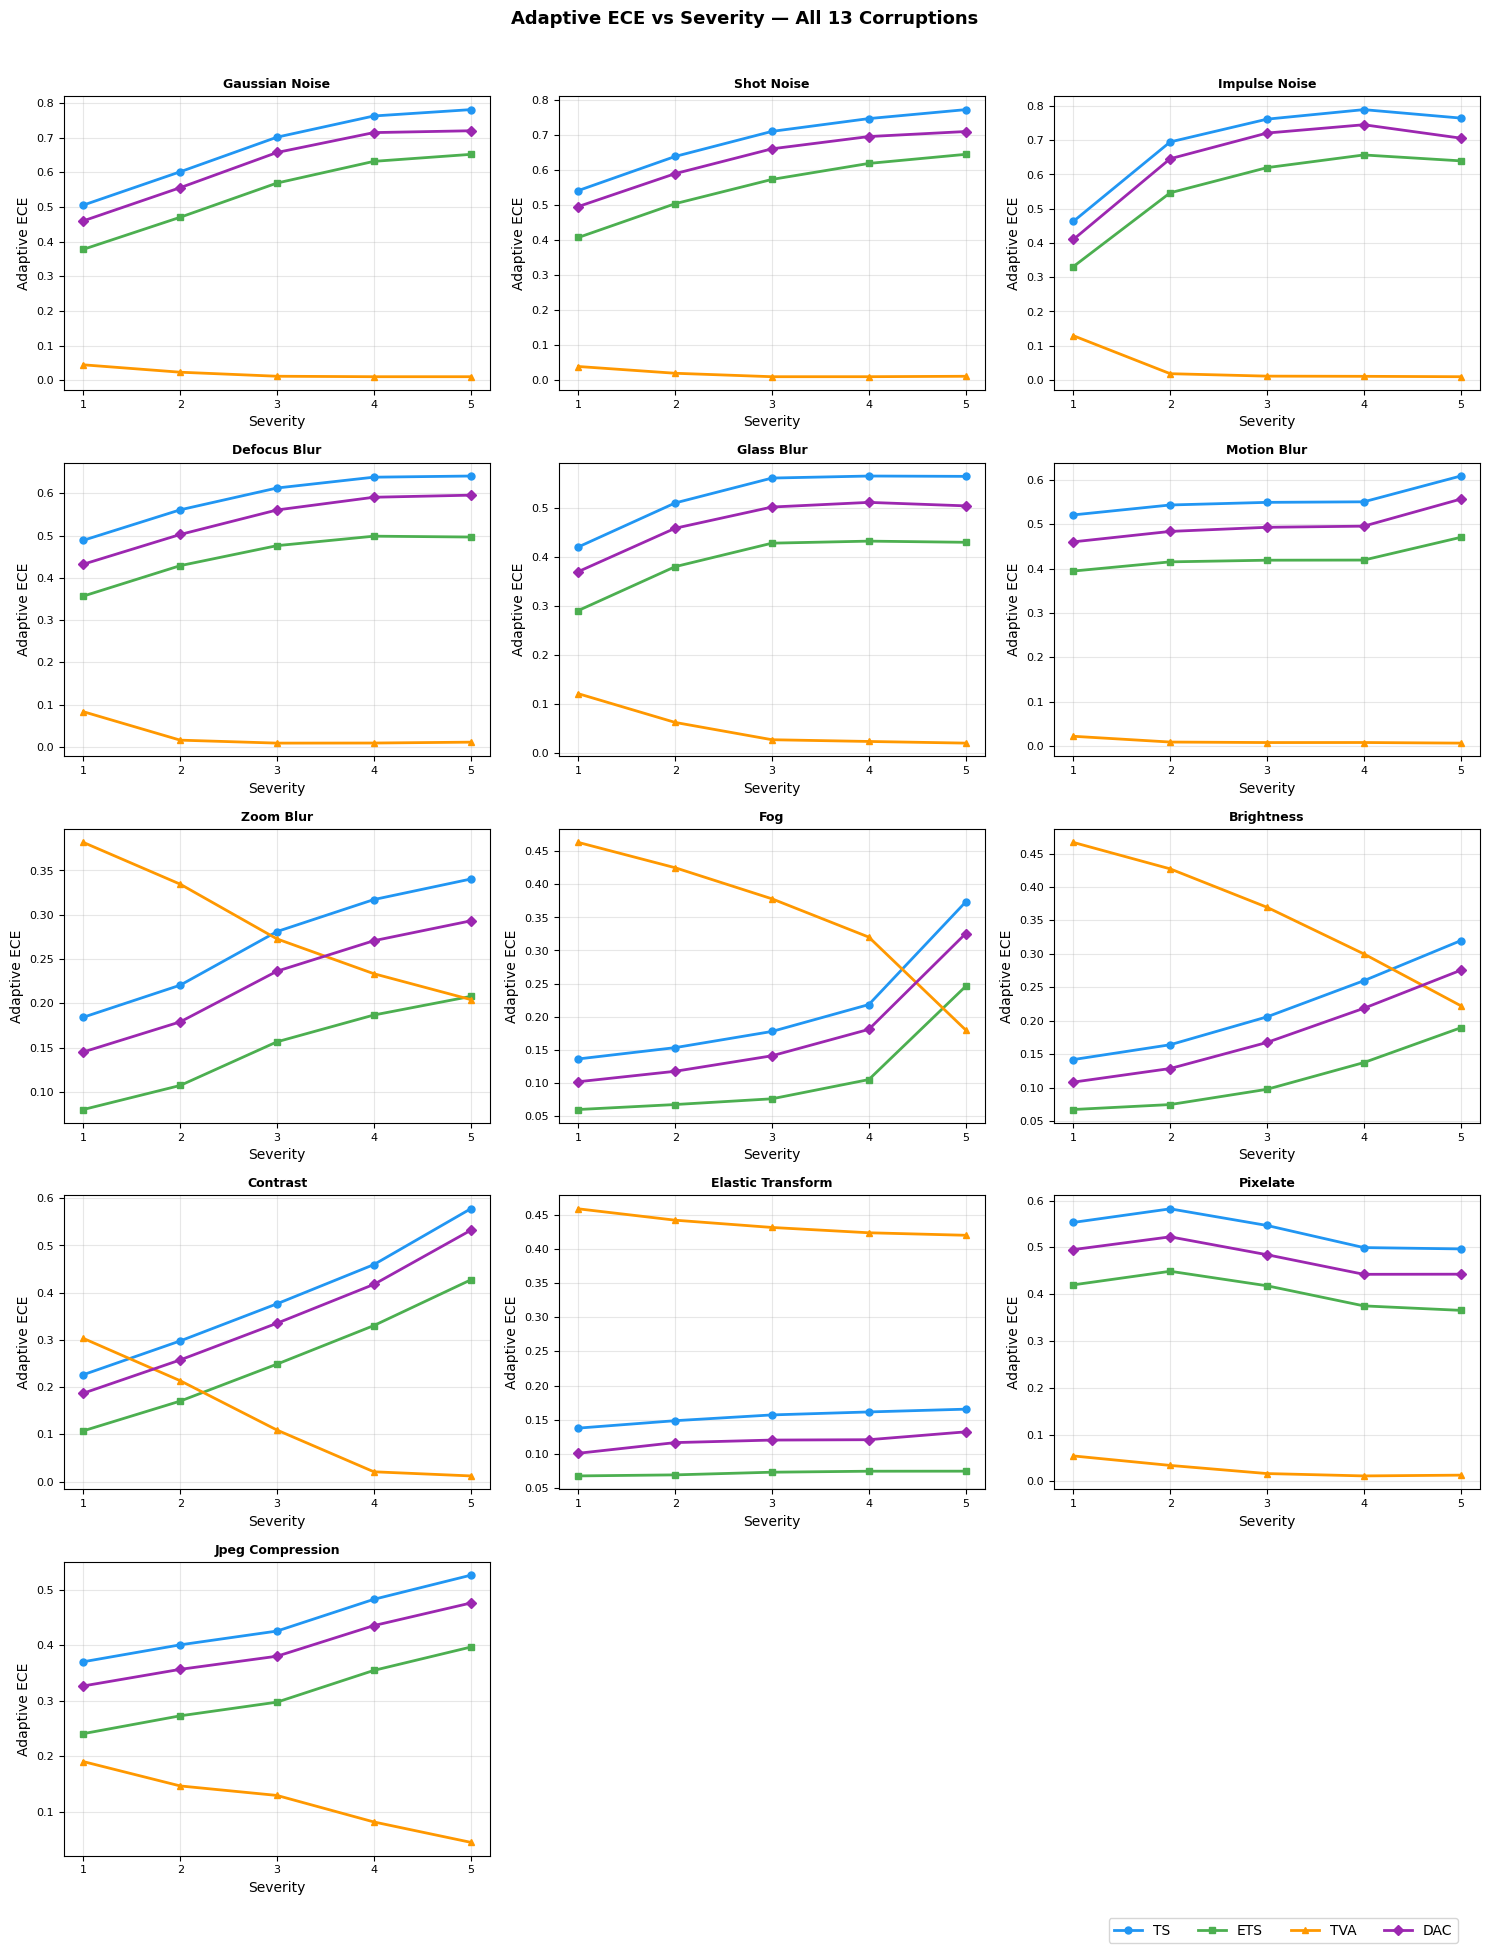

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows), sharey=False)
fig.suptitle('Adaptive ECE vs Severity — All 13 Corruptions', fontsize=13, fontweight='bold')

for i, corr in enumerate(CORRUPTIONS):
    ax = axes.flat[i]
    for m in METHODS:
        ada_eces = [results[m]['corruptions'][corr][str(s)]['adaptive_ece']
                    for s in SEVERITIES]
        ax.plot(SEVERITIES, ada_eces, marker=MARKERS[m], color=COLORS[m],
                lw=2, ms=5, label=m.upper())
    ax.set_title(corr.replace('_',' ').title(), fontsize=9, fontweight='bold')
    ax.set_xticks(SEVERITIES)
    ax.set(xlabel='Severity', ylabel='Adaptive ECE')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

for j in range(len(CORRUPTIONS), len(axes.flat)):
    axes.flat[j].set_visible(False)

handles, labels_leg = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower right',
           fontsize=10, ncol=len(METHODS), bbox_to_anchor=(0.98, 0.01))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


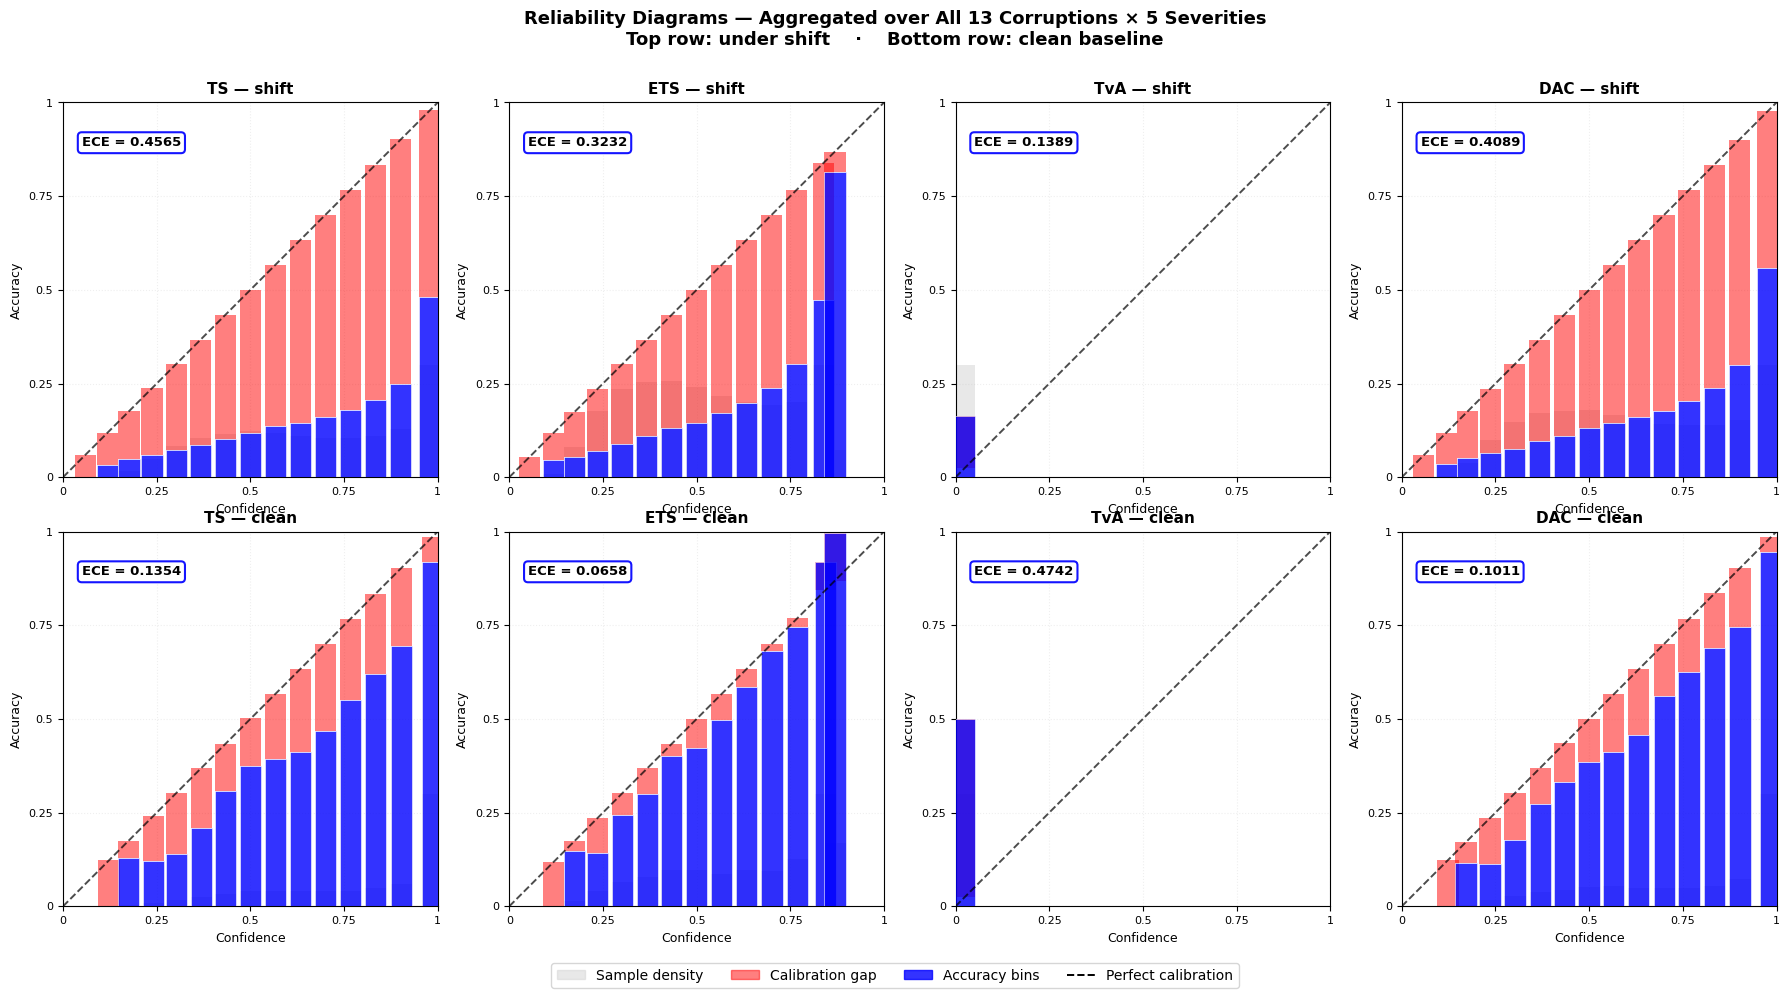

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N_BINS = 15


def aggregate_bins_from_json(method_key, condition='shift'):
    bin_edges   = np.linspace(0, 1, N_BINS + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    sum_conf  = np.zeros(N_BINS)
    sum_acc   = np.zeros(N_BINS)
    sum_n     = np.zeros(N_BINS)

    if condition == 'clean':
        conditions = [results[method_key]['clean_baseline']]
    else:
        conditions = [
            results[method_key]['corruptions'][c][str(s)]
            for c in CORRUPTIONS for s in SEVERITIES
        ]

    for d in conditions:
        for i, b in enumerate(d['bins']):
            if b['n'] > 0 and b['acc'] is not None:
                sum_conf[i] += b['conf'] * b['n']
                sum_acc[i]  += b['acc']  * b['n']
                sum_n[i]    += b['n']

    valid = sum_n > 0
    bin_confs = bin_centers.copy()
    bin_accs  = np.full(N_BINS, np.nan)

    bin_confs[valid] = sum_conf[valid] / sum_n[valid]
    bin_accs[valid]  = sum_acc[valid]  / sum_n[valid]

    return bin_confs, bin_accs, sum_n


def plot_reliability(ax, bin_confs, bin_accs, bin_counts, title, n_bins=N_BINS):

    bin_w  = (1 / n_bins) * 0.85
    valid  = ~np.isnan(bin_accs)
    total  = bin_counts[valid].sum()

    ece = float(np.sum(
        bin_counts[valid] / total * np.abs(bin_accs[valid] - bin_confs[valid])
    ))

    # ── confidence histogram (gray) ───────────────────────────────────
    hist_h = bin_counts / bin_counts[valid].max() * 0.3
    ax.bar(bin_confs, hist_h, width=bin_w,
           color='lightgray', alpha=0.5, zorder=1)

    # ── gap bars (RED) ────────────────────────────────────────────────
    for i in range(n_bins):
        if not valid[i]:
            continue
        gap = bin_accs[i] - bin_confs[i]
        ax.bar(bin_confs[i], abs(gap),
               bottom=min(bin_accs[i], bin_confs[i]),
               width=bin_w, color='red', alpha=0.5, zorder=2)

    # ── accuracy bins (BLUE) ──────────────────────────────────────────
    ax.bar(bin_confs[valid], bin_accs[valid],
           width=bin_w, color='blue', alpha=0.8,
           edgecolor='white', linewidth=0.5, zorder=3)

    # ── diagonal ──────────────────────────────────────────────────────
    ax.plot([0, 1], [0, 1], 'k--', lw=1.4, alpha=0.7, zorder=5)

    # ── ECE annotation ────────────────────────────────────────────────
    ax.text(0.05, 0.91, f'ECE = {ece:.4f}',
            transform=ax.transAxes, fontsize=9.5, fontweight='bold',
            va='top',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='blue',
                      linewidth=1.5, alpha=0.92))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(['0', '0.25', '0.5', '0.75', '1'], fontsize=8)
    ax.set_yticklabels(['0', '0.25', '0.5', '0.75', '1'], fontsize=8)

    ax.set_xlabel('Confidence', fontsize=9)
    ax.set_ylabel('Accuracy', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

    ax.set_aspect('equal')
    ax.grid(alpha=0.2, linestyle=':')


# ── Build and plot ─────────────────────────────────────────────────────
METHOD_LABELS = {'ts': 'TS', 'ets': 'ETS', 'tva': 'TvA', 'dac': 'DAC'}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle(
    'Reliability Diagrams — Aggregated over All 13 Corruptions × 5 Severities\n'
    'Top row: under shift    ·    Bottom row: clean baseline',
    fontsize=13, fontweight='bold', y=0.99
)

for j, m in enumerate(METHODS):
    lbl = METHOD_LABELS[m]

    bc_s, ba_s, bw_s = aggregate_bins_from_json(m, 'shift')
    plot_reliability(axes[0, j], bc_s, ba_s, bw_s,
                     f'{lbl} — shift')

    bc_c, ba_c, bw_c = aggregate_bins_from_json(m, 'clean')
    plot_reliability(axes[1, j], bc_c, ba_c, bw_c,
                     f'{lbl} — clean')


# ── shared legend ─────────────────────────────────────────────────────
patches = [
    mpatches.Patch(color='lightgray', alpha=0.5, label='Sample density'),
    mpatches.Patch(color='red', alpha=0.5, label='Calibration gap'),
    mpatches.Patch(color='blue', alpha=0.8, label='Accuracy bins'),
    plt.Line2D([0],[0], color='black', lw=1.4, ls='--', label='Perfect calibration'),
]

fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, 0.005), frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

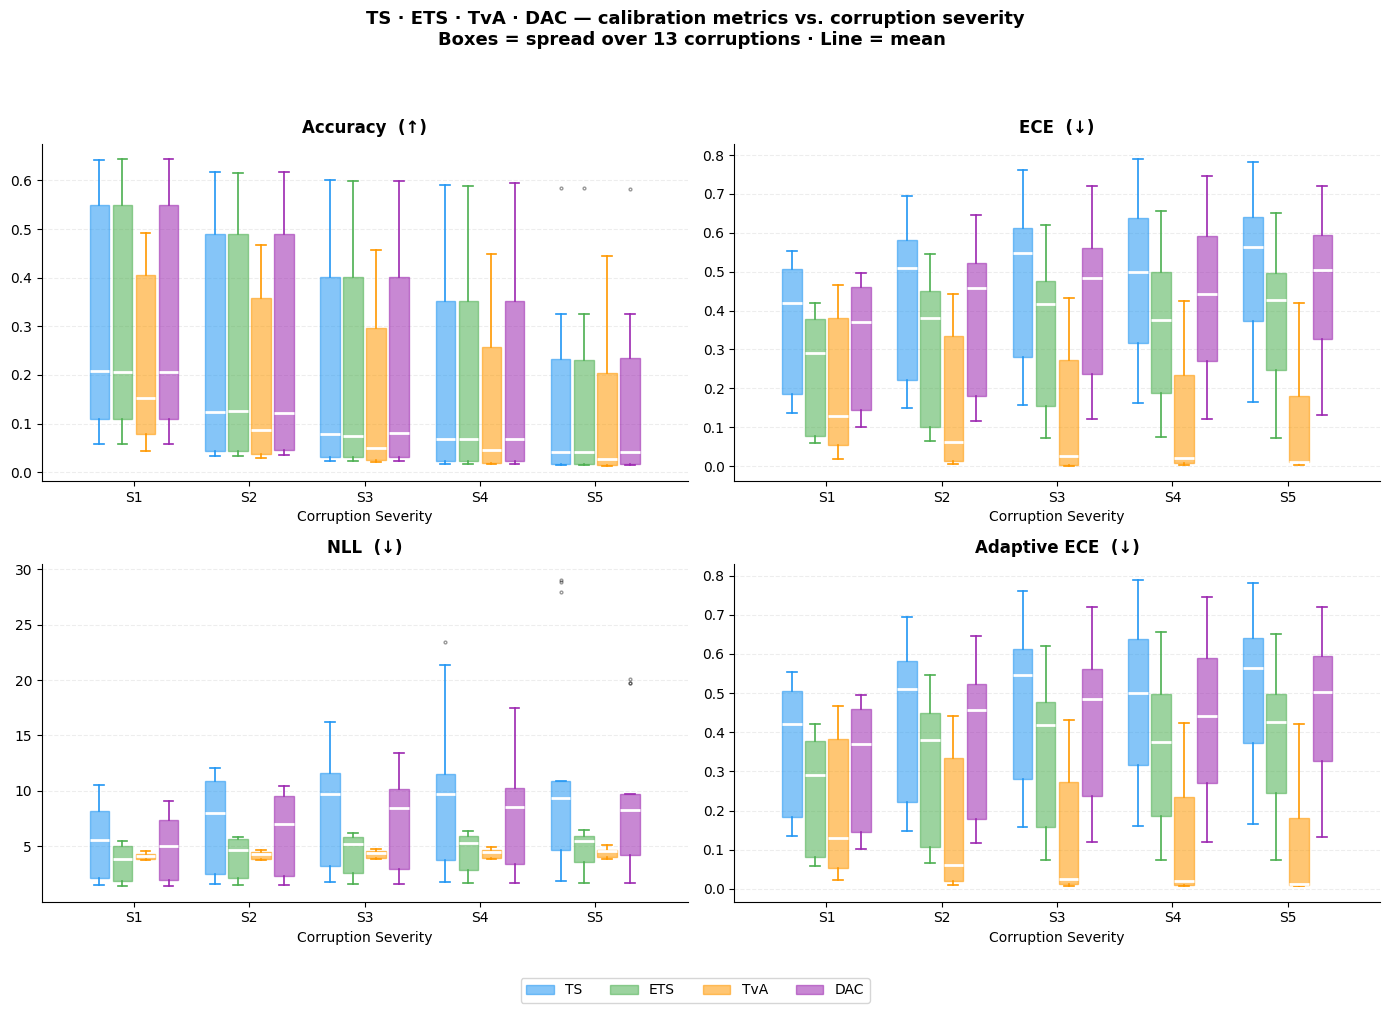

In [28]:
METRICS_FIG2  = ['accuracy', 'ece', 'nll', 'adaptive_ece']
METRIC_LABEL2 = {
    'accuracy':   'Accuracy  (↑)',
    'ece':        'ECE  (↓)',
    'nll':        'NLL  (↓)',
    'adaptive_ece': 'Adaptive ECE  (↓)',
}

METHOD_LABELS = {'ts': 'TS', 'ets': 'ETS', 'tva': 'TvA', 'dac': 'DAC'}

OFFSETS = {'ts': -0.30, 'ets': -0.10, 'tva': +0.10, 'dac': +0.30}
BOX_W   = 0.17


def vals_per_severity(method, metric):
    return [
        np.array([results[method]['corruptions'][c][str(s)][metric]
                  for c in CORRUPTIONS])
        for s in SEVERITIES
    ]


# ── 2×2 grid ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, METRICS_FIG2):

    for m in METHODS:
        data      = vals_per_severity(m, metric)
        positions = [s + OFFSETS[m] for s in SEVERITIES]

        ax.boxplot(
            data,
            positions=positions,
            widths=BOX_W,
            patch_artist=True,
            notch=False,
            medianprops=dict(color='white', lw=2),
            whiskerprops=dict(color=COLORS[m], lw=1.2),
            capprops=dict(color=COLORS[m], lw=1.2),
            flierprops=dict(marker='.', color=COLORS[m], alpha=0.4, ms=4),
            boxprops=dict(facecolor=COLORS[m], alpha=0.55, color=COLORS[m]),
        )

    ax.set_title(METRIC_LABEL2[metric], fontsize=12, fontweight='bold', pad=8)
    ax.set_xticks(SEVERITIES)
    ax.set_xticklabels([f'S{s}' for s in SEVERITIES])
    ax.set_xlabel('Corruption Severity', fontsize=10)
    ax.grid(alpha=0.22, linestyle='--', axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ── Legend (methods + baseline) ─────────────────────────────────────────────
handles = [
    mpatches(facecolor=COLORS[m], edgecolor=COLORS[m], alpha=0.55,
          label=METHOD_LABELS[m])
    for m in METHODS
]




fig.legend(
    handles=handles,
    loc='lower center',
    ncol=5,
    fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01),
)


# ── Global title ────────────────────────────────────────────────────────────
fig.suptitle(
    'TS · ETS · TvA · DAC — calibration metrics vs. corruption severity\n'
    'Boxes = spread over 13 corruptions · Line = mean ',
    fontsize=13, fontweight='bold', y=1.01,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig('checkpoints/fig2_all_methods_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
rows = []
for m in METHODS:
    cb  = results[m]['clean_baseline']
    all_ece, all_ada, all_nll, all_acc = [], [], [], []
    ece_s5 = []
    for c in CORRUPTIONS:
        for s in SEVERITIES:
            d = results[m]['corruptions'][c][str(s)]
            all_ece.append(d['ece'])
            all_ada.append(d['adaptive_ece'])
            all_nll.append(d['nll'])
            all_acc.append(d['accuracy'])
        ece_s5.append(results[m]['corruptions'][c][str(5)]['ece'])

    rows.append({
        'Method'           : m.upper(),
        'Clean Acc'        : f"{cb['accuracy']:.4f}",
        'Clean ECE'        : f"{cb['ece']:.4f}",
        'Mean Acc (shift)' : f"{np.mean(all_acc):.4f}",
        'Mean ECE (shift)' : f"{np.mean(all_ece):.4f}",
        'Mean AdaECE'      : f"{np.mean(all_ada):.4f}",
        'Mean NLL (shift)' : f"{np.mean(all_nll):.4f}",
        'ECE @ Severity 5' : f"{np.mean(ece_s5):.4f}",
    })

df_summary = pd.DataFrame(rows).set_index('Method')
print("=== Ovadia++ Full Benchmark Summary ===")
display(df_summary)


=== Ovadia++ Full Benchmark Summary ===


,Clean Acc,Clean ECE,Mean Acc (shift),Mean ECE (shift),Mean AdaECE,Mean NLL (shift),ECE @ Severity 5
Method,,,,,,,
TS,0.6533,0.1347,0.2130,0.4562,0.4562,8.6457,0.5332
ETS,0.6533,0.0658,0.2128,0.3331,0.3333,4.2855,0.4033
TVA,0.4988,0.4742,0.1630,0.1417,0.1437,4.2989,0.0881
DAC,0.6533,0.1010,0.2132,0.4089,0.4088,7.2658,0.4823


## 10. Interpretation of Results

### ETS is the clear winner

ETS halves the clean ECE from 0.135 (TS) to 0.066 without touching accuracy. Under shift the improvement is even starker: mean NLL drops from 8.65 to 4.29 — a **4.5× reduction on gaussian noise at severity 5** (28.9 → 6.5). To put that in context, a completely uniform predictor over 100 classes has NLL of $\log(100) \approx 4.6$. ETS at its worst barely exceeds this, while TS at severity 5 noise is more than **6× worse than random** in NLL terms. That is not a small difference — it means TS is not just miscalibrated under heavy noise, it is actively destructive as a probabilistic predictor.

The reason ETS holds up is structural. The uniform mixing weight $w_3$ provides a hard floor: no matter how corrupted the input, the output is a mixture that includes $w_3 / K$ for every class. This prevents the extreme logit magnitudes that corrupted images produce from translating into extreme softmax probabilities. ETS doesn't detect corruption — it just can't be as wrong as TS.

Looking at individual corruptions confirms this. On fog at severity 5, ETS achieves ECE=0.236 vs TS=0.372 — a 36% improvement. On elastic transform (a benign corruption that barely shifts the distribution), ETS holds ECE at 0.075 across all 5 severities, nearly matching its clean baseline of 0.066.

---

### TS collapses under noise (same as in [Ovadia et al. (2019)](https://arxiv.org/abs/1906.02629)'conclusion)

The three noise corruptions (gaussian, shot, impulse) are where TS fails most dramatically. On gaussian noise at severity 5: accuracy drops to 1.5%, but ECE hits 0.778 and NLL reaches 28.9. The model is assigning very high confidence to wrong classes on images that look like pure noise. This is the exact failure Ovadia warned about — the model has no idea it's looking at garbage, and the fixed temperature does nothing to signal uncertainty.

DAC does better on noise than TS (ECE 0.719 vs 0.778 at gaussian s5) but the improvement is modest. The logit-space distance proxy partially detects the noise distribution shift but doesn't fully compensate — noisy images produce high-magnitude logits that push NLL to 20 even with adaptive temperature.

---

### The TvA paradox — low ECE ≠ good calibration

TvA starts with clean ECE of **0.474** — catastrophically miscalibrated before any corruption is applied. Under shift, however, its ECE *falls* — reaching 0.003 on pixelate at severity 5, and 0.010 on gaussian noise. The brightness plot showed this directly: TvA's orange curve slopes downward while every other method slopes up.

This is not robustness. It is two errors cancelling.

TvA's 200 per-class logistic scalers $(a_k, b_k)$ were fit on 5,000 clean validation samples. The model is overconfident on clean data, and TvA's per-class corrections — trained to fix this — push probabilities down aggressively. On clean data they push too hard, making the model *underconfident* and causing ECE=0.474. Under heavy corruption the model's logits shrink and flatten because corrupted CIFAR-100 images produce weak activations. The model naturally becomes less confident — but TvA is still applying the same downward correction on top. The result is that confidence drops to near $1/K$ just as accuracy also drops to near $1/K$ (1.4% on gaussian noise at s5 ≈ random for 100 classes). When both confidence and accuracy are near $1/100$, ECE is near zero *by construction*.

The NLL exposes this: TvA's NLL on gaussian noise at severity 5 is 5.11, which is only slightly above the uniform predictor's 4.61. TvA has essentially learned to output nearly uniform distributions for corrupted inputs, which gives good ECE but means it has no discriminative information left. The accuracy penalty confirms it: TvA achieves only 0.498 on clean data vs 0.653 for the others, a 15% accuracy loss that is entirely caused by the miscalibrated scalers disrupting the argmax.

There is one exception: **elastic transform**, where TvA has ECE=0.421 at severity 5, the worst of any method on that corruption. Elastic transform barely changes image statistics; the model's logits barely change, so TvA's aggressive scaling still fires at full strength but the accuracy doesn't drop to compensate. The illusion fails here and the poor calibration is exposed.

---

### DAC — right idea, imprecise proxy

DAC improves on TS across the board: clean ECE drops from 0.135 to 0.101, mean ECE under shift from 0.456 to 0.409. But it never comes close to ETS. The core problem is that the logit-space $L_2$ distance to the validation mean is too crude an OOD signal for CIFAR-100.

Consider fog: at severity 1, fog barely changes image content and DAC's distance $d(x)$ is small → adaptive temperature stays near $T_\text{base}$ → behaviour close to TS. But ETS already achieves ECE=0.062 on fog severity 1 because its uniform component provides a universal hedge. DAC can only help when $d(x)$ is large, which requires strong corruption. For moderate corruptions (brightness, elastic transform, zoom blur) DAC offers little over TS, while ETS reliably outperforms both.

The NLL trajectory for DAC is also concerning: on gaussian noise it goes 7.4 → 9.6 → 12.9 → 16.6 → 20.0 across severities 1–5. The adaptive temperature is growing with $d(x)$, but it's growing *too slowly* relative to the logit explosion that severe noise causes. A better OOD proxy — Mahalanobis distance in penultimate feature space, or kNN density — would likely fix this.

---

### Per-corruption taxonomy findings

**Noise corruptions** are the hardest for every method. TS and DAC collapse; ETS degrades but stays bounded. TvA accidentally reaches near-zero ECE via the cancellation mechanism above.

**Blur corruptions** show more nuance. On zoom blur — which is unusual because it preserves image structure while zooming in — all methods except TvA perform reasonably well. TS ECE at zoom severity 5 is only 0.340, far better than its 0.778 on gaussian noise. The model can still identify zoomed objects; it just becomes progressively more uncertain, and TS's fixed temperature partially tracks this because the logit magnitudes shrink naturally with zoom corruption.

**Weather corruptions** split cleanly: fog is moderate (ETS shines, reaching ECE=0.236 at s5); brightness is benign (ETS stays at 0.191 at s5, basically in-distribution territory); contrast is severe (TS ECE=0.578 at s5, similar to gaussian noise). Contrast is essentially a global darkening to near-black at severity 5 — the model sees structureless images and fires high-confidence predictions on pure noise, the same failure mode as gaussian noise.

**Digital corruptions** are a mixed bag. Elastic transform is genuinely benign — all methods maintain near-clean performance. JPEG compression hurts significantly (TS ECE=0.526 at s5) because it destroys the fine texture details that a 32×32 model relies on. Pixelation is interesting: ECE is high but NLL plateaus for TS and DAC at severity 3–5, suggesting the model becomes uniformly wrong in a stable way once the image is pixelated enough.

---

### ECE vs Adaptive ECE — do they agree?

For TS, DAC, and ETS the two metrics are essentially identical (differences in the 4th decimal place), confirming that their confidence distributions are not pathologically skewed and the fixed-bin estimate is unbiased. For TvA the two metrics can diverge slightly (particularly at intermediate severities) because TvA's per-class sigmoid normalisation produces non-standard confidence distributions that don't cluster at the high end the way softmax does. The adaptive ECE is the more trustworthy number for TvA.


# Conclusion

### What we did

We reproduced the Guo et al. (2017) temperature scaling baseline, trained a DenseNet-BC-40 from scratch on CIFAR-100, and ran a systematic evaluation across 13 corruption types and 5 severity levels — the Ovadia++ benchmark. Alongside vanilla TS we implemented three post-hoc calibrators published after Ovadia (2019): ETS, TvA, and DAC.

---

### What the results say, corruption by corruption

The benchmark shows that no single method is universally best, but ETS is consistently the safest choice:

- **On noise corruptions** (gaussian, shot, impulse): ETS is 4–5× better in NLL than TS. DAC helps but not enough. TvA achieves near-zero ECE via an artefact, not genuine robustness.
- **On blur corruptions** (defocus, glass, motion, zoom): zoom blur is the most revealing — all methods except TvA perform reasonably because the image structure is preserved. ETS leads.
- **On weather corruptions** (fog, brightness, contrast): fog and brightness are where ETS is most clearly better than TS. Contrast at severity 5 is catastrophic for everyone — the images become nearly black.
- **On digital corruptions** (elastic, pixelate, JPEG): elastic transform is almost benign. JPEG and pixelate hurt significantly. ETS consistently maintains the best ECE.

---

### The three key takeaways

**1. TS is not enough under shift.** A mean NLL of 8.65 under corruption, reaching 28.9 on gaussian noise at severity 5, is not a calibrated model — it is a confidently wrong model. A uniform predictor scores 4.61 on NLL. TS is 6× worse than random at severe noise. This confirms Ovadia and quantifies the failure precisely.

**2. ETS is a free upgrade.** Four parameters instead of one, same training time, same accuracy, mean ECE 27% lower under shift, NLL halved. The uniform mixing component provides a structural ceiling on overconfidence that costs nothing. There is no good reason to use vanilla TS over ETS.

**3. Low ECE can be misleading.** TvA's near-zero ECE at high severity is the most important cautionary result. It arises from the model's confidence accidentally matching its (very low) accuracy — both collapse toward $1/K$ under heavy corruption. This is not calibration. NLL=5.11 on gaussian noise at s5 exposes it: TvA is outputting near-uniform distributions and has essentially given up on the prediction. Always check NLL alongside ECE when evaluating calibration under shift.

---

### What would make this better

**Better OOD proxy for DAC.** The logit-space $L_2$ distance is noisy. Mahalanobis distance in penultimate feature space, or kNN density estimation, would give a more reliable signal of how OOD an input is — likely closing the gap with ETS on noise corruptions.

**More validation data for TvA.** With 5,000 samples and 200 parameters, TvA is on the edge of overfitting. With 20,000 samples the per-class scalers would be more stable, and the clean baseline ECE would likely drop from 0.474 to something reasonable.

**Larger, better-regularised models.** DenseNet-BC-40 is small and trained with no label smoothing or modern augmentation. Modern models trained with mixup or CutMix are already better calibrated to start with, and the question of whether these post-hoc methods still add value in that regime is open and practically important.

---

### Final answer to the opening question

*Is temperature scaling good because it is correct, or because benchmarks are easy?*

Both, but mostly the second. On clean CIFAR-100 it is a genuinely good calibrator. The moment the distribution shifts, the single fixed scalar has no mechanism to respond. ETS shows that even a minimal structural addition (a uniform prior with weight 0.1–0.2) dramatically improves robustness without any access to corrupted data at fitting time. The field has moved since Ovadia 2019, and the move has been productive. But the honest conclusion is that all post-hoc methods are working around a model that was never trained to be uncertain, and there is a ceiling to how much you can fix at calibration time.
